# Интерпретация

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay, permutation_importance
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

from PyALE import ale
import matplotlib.pyplot as plt

# import lime
# import lime.lime_tabular

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'


### Загрузка и подготовка данных


Вам будет предоставлен датасет, посвященный продаже недвижимости. Ваша задача - построить интерпретацию для этого датасета. В нем достаточно много различных признаков, поэтому вы можете предварительно отфильтровать их, когда будете строить графики. Оставляйте достаточно признаков, чтобы ваши модели оставались точными..

In [2]:
data_path = r'/Users/admin/projects_/spbu_ml_2026/datasets/hw1/data.csv'
data = pd.read_csv(data_path, sep=',')

print(f"Размер датасета: {data.shape}")
print(f"\nПервые строки:")
data.head()


Размер датасета: (29905, 83)

Первые строки:


,region_name_cat,district_cat,corpus_cat,developer_cat,agreement_date,floor,square,rooms_4,location_logs_count_mean,location_depth,...,location_public_transport_platform_w_mean_distance,location_water_w_mean_distance,location_university_w_mean_distance,location_leisure_w_mean_distance,location_pop_shop_cnt,price_target,hc_name_cat,interior_cat,class_cat,stage_cat
0,Город,45,538,18,2012-08-10,3.0,62.23,2,22.550466,13.0,...,0.910028,0.782675,-999.000000,0.820073,16.0,28417.424671,50,49786.0,27353,7983
1,Пригород,48,432,63,2013-05-19,11.0,22.52,студия,22.581858,13.0,...,0.902510,0.902673,-999.000000,0.990908,18.0,16728.215463,293,49786.0,97865,70661
2,Город,44,2372,126,2012-12-12,3.0,38.17,1,20.191250,13.0,...,0.851637,-999.000000,-999.000000,0.945618,7.0,18311.834458,284,49786.0,97865,70661
3,Город,14,1053,121,2012-12-10,10.0,57.48,2,23.286900,13.0,...,0.913797,1.028386,0.300026,0.828147,5.0,25171.489968,325,0.0,97865,12638
4,Город,63,2426,69,2012-02-12,3.0,41.43,1,20.599150,13.0,...,1.051049,-999.000000,-999.000000,0.991506,4.0,27324.795343,182,49786.0,97865,70661


## Задание 1. 1 балл
Сделайте 2 версии данных - с нормализацией признаков и без.
Обучите 6 моделей:
- линейную регрессию (LinearRegression) на двух вариантах данных
- Lasso регрессию (Lasso) на двух вариантах данных
- градиентный бустинг (GradientBoostingRegressor) на двух вариантах данных. Ограничьте глубину до 5.

Выведите MSE,RMSE и MAPE моделей. Какая функция больше подходит? Почему?

Зафиксируйте выводы. Какие модели чувствительны к масштабу признаков, а какие почти инвариантны? Почему это важно для анализа признаков?

In [3]:
target_col = 'price_target'

data['rooms_4'] = data['rooms_4'].replace({'студия': 0, '>=4': 4}).astype(float) #студия - 0 комнат будем считать

num_cols = data.select_dtypes(include=['number']).columns.tolist() 

if target_col in num_cols:
    num_cols.remove(target_col)

df = data[num_cols + [target_col]].replace(-999.0, np.nan).dropna()
X_train, X_test, y_train, y_test = train_test_split(df[num_cols], df[target_col], test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(),
    'Gradient Boosting': GradientBoostingRegressor(max_depth=5, random_state=42)
}

print(f"{'Модель':<20} | {'Скейлинг':<10} | {'MSE':<12} | {'RMSE':<10} | {'MAPE'}")
print("-" * 70)

for name, model in models.items():
    for scale_name, X_tr, X_te in [('No scale', X_train, X_test), ('Scaled', X_train_scaled, X_test_scaled)]:
        
        model.fit(X_tr, y_train)
        pred = model.predict(X_te)
        
        mse = mean_squared_error(y_test, pred)
        mape = mean_absolute_percentage_error(y_test, pred) * 100
        
        print(f"{name:<20} | {scale_name:<10} | {mse:<12.1f} | {mse**0.5:<10.1f} | {mape:.2f}%")

Модель               | Скейлинг   | MSE          | RMSE       | MAPE
----------------------------------------------------------------------
Linear Regression    | No scale   | 5209058.3    | 2282.3     | 4.54%
Linear Regression    | Scaled     | 5209058.3    | 2282.3     | 4.54%
Lasso                | No scale   | 5238255.3    | 2288.7     | 4.55%
Lasso                | Scaled     | 5222078.0    | 2285.2     | 4.54%
Gradient Boosting    | No scale   | 3934121.1    | 1983.5     | 3.65%
Gradient Boosting    | Scaled     | 3962839.6    | 1990.7     | 3.65%


Лучше всего подходит MAPE, тк наиболее понятная, показывает относительную ошибку в процентах. Линейная регрессия и градиентный бустинг инвариантны, у линейной важен не само значение веса а соотношение, а у градиентного бустинга структура дерева не изменится. Лассо по идее должна быть более чувствительна но здесь почему то тоже в пределах погрешности получилось_? Нормализация важна для анализа признаков потому что без нее нельзя объективно оценивать разницу кожффициентов у признаков

## Задание 1.1(*) 1 балл
Сравните модели, построенные с помощью разных видов нормализации (MinMax, Standart). Отличается ли важность признаков?

Модель               | MSE          | RMSE       | MAPE
------------------------------------------------------------
LinReg (No_scale)    | 5209058.3    | 2282.3     | 4.54%
Lasso (No_scale)     | 5238255.3    | 2288.7     | 4.55%
GB (No_scale)        | 3934121.1    | 1983.5     | 3.65%
LinReg (Standard)    | 5209058.3    | 2282.3     | 4.54%
Lasso (Standard)     | 5222078.0    | 2285.2     | 4.54%
GB (Standard)        | 3962839.6    | 1990.7     | 3.65%
LinReg (MinMax)      | 5209058.3    | 2282.3     | 4.54%
Lasso (MinMax)       | 5235125.4    | 2288.0     | 4.54%
GB (MinMax)          | 3905567.4    | 1976.3     | 3.65%


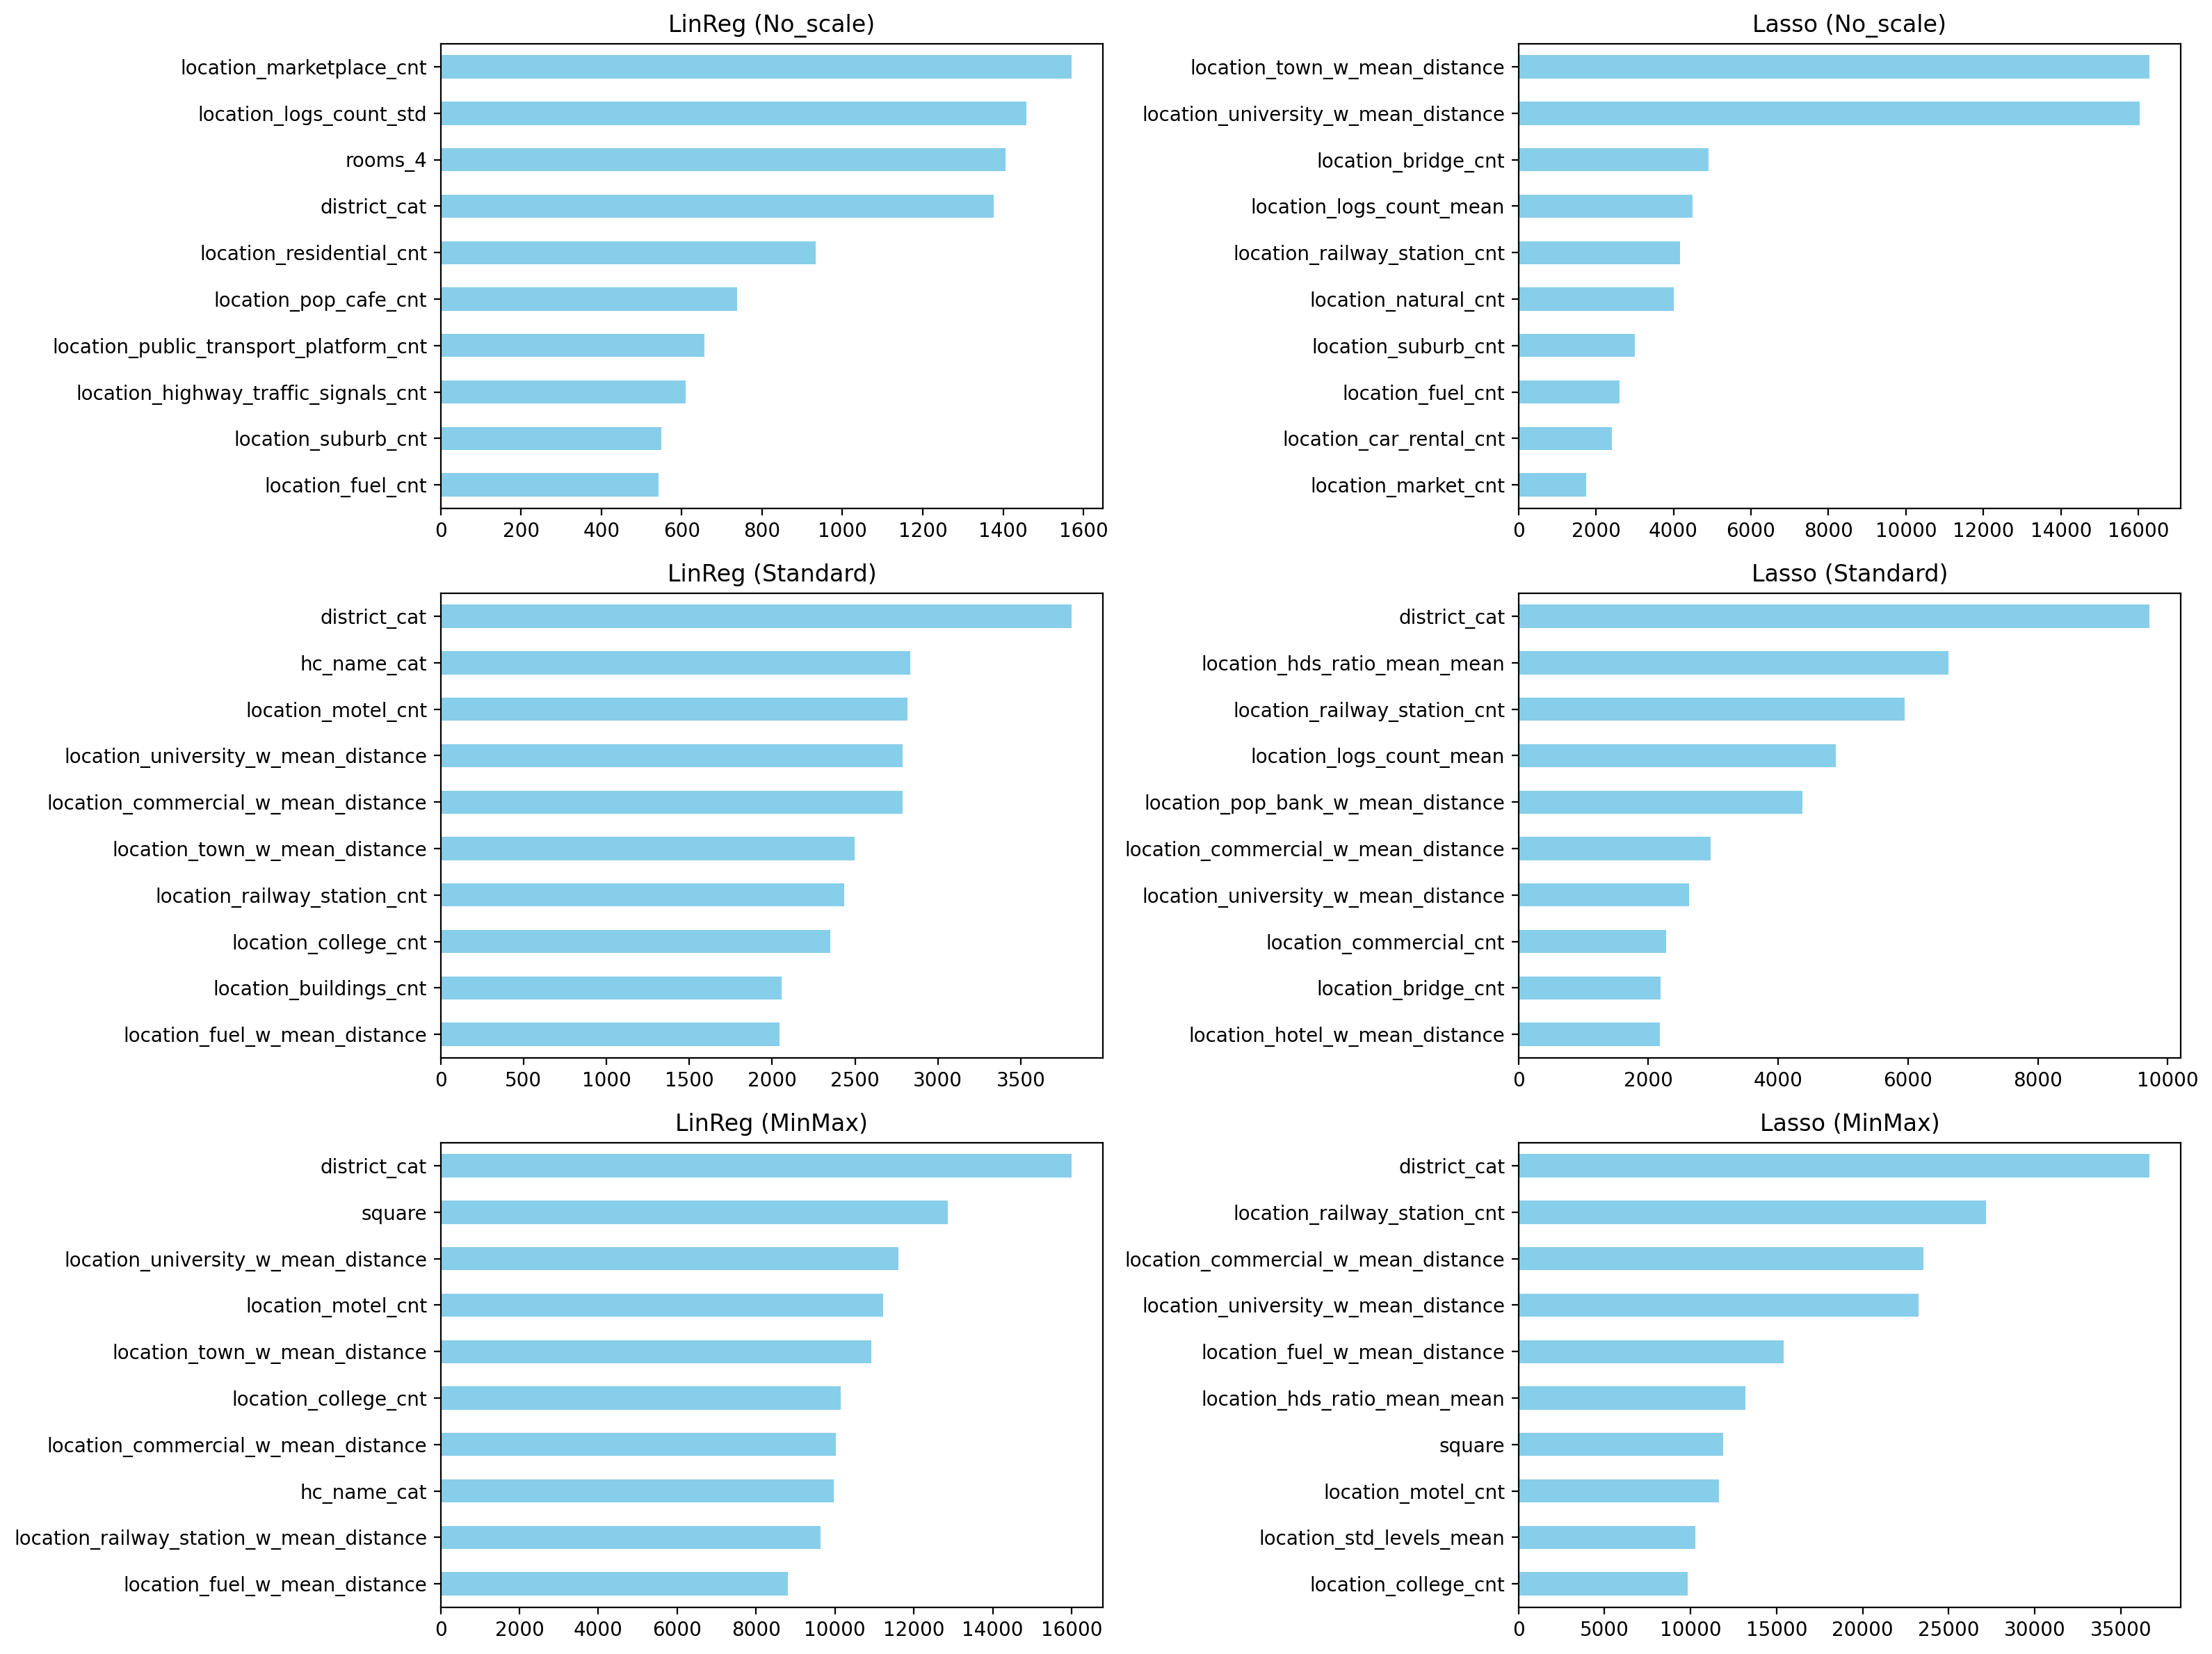

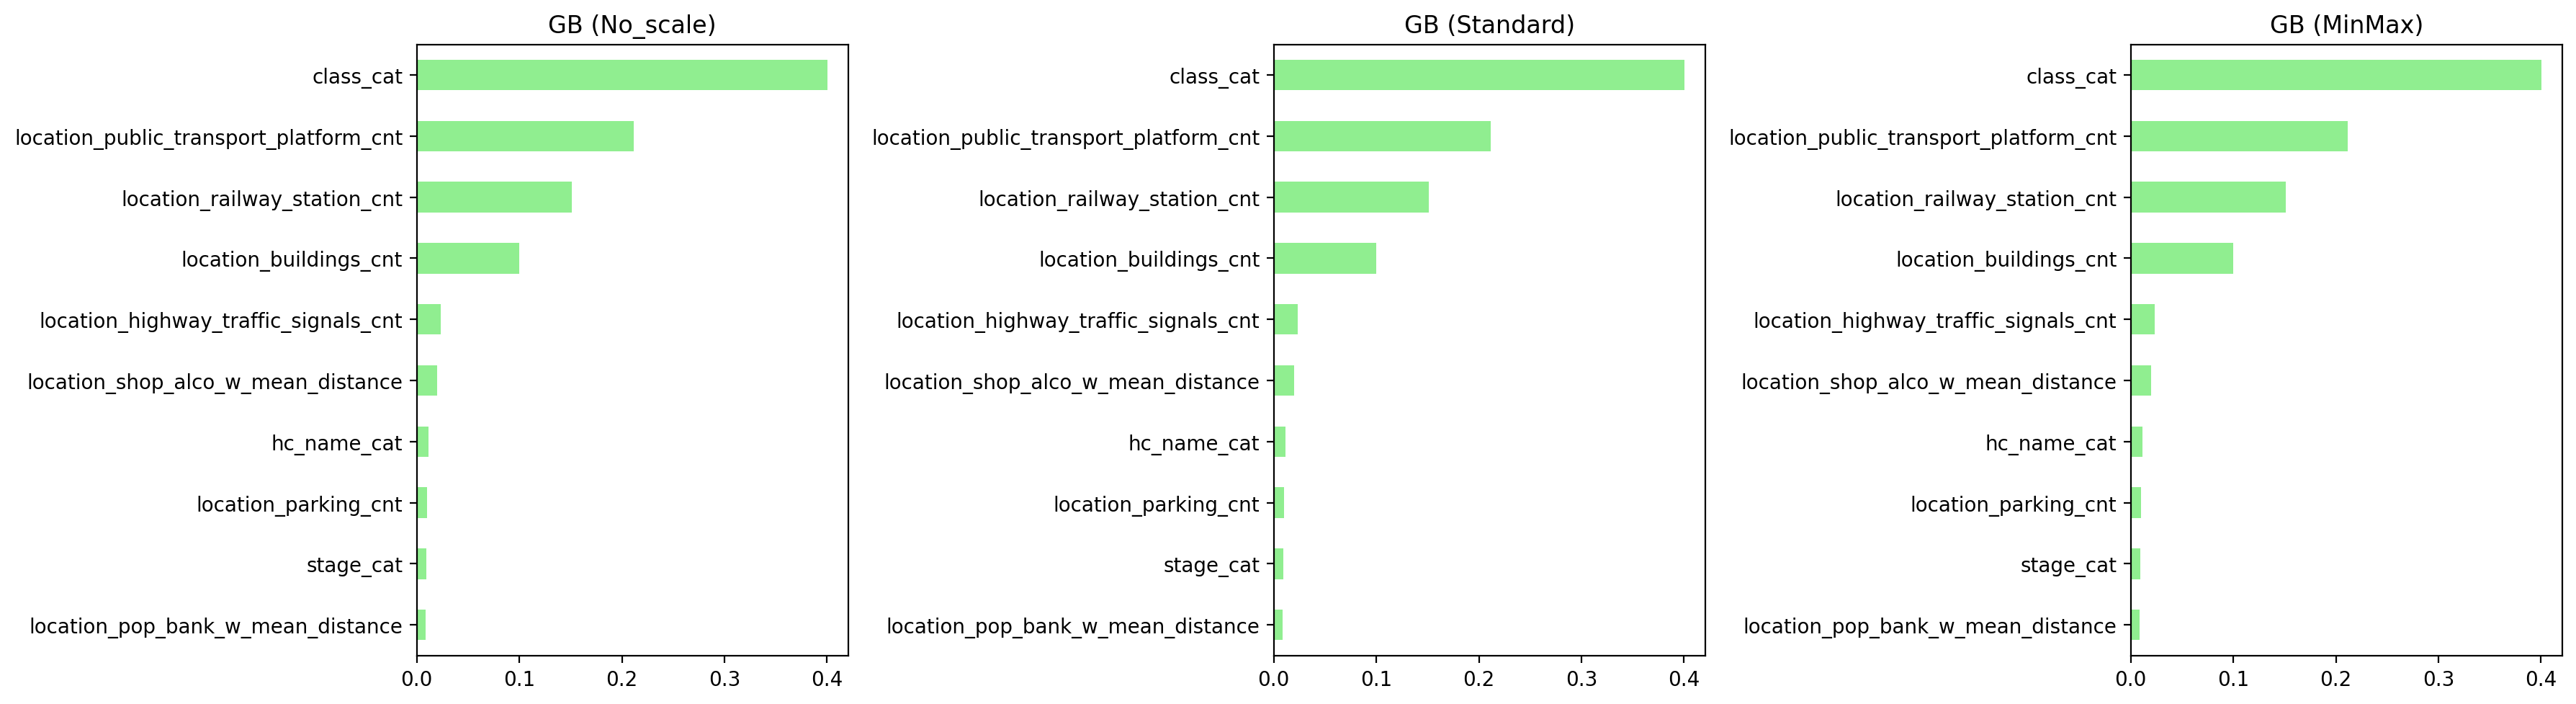

In [15]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

scalers = {
    'No_scale': (X_train, X_test),
    'Standard': (StandardScaler().fit_transform(X_train), StandardScaler().fit(X_train).transform(X_test)),
    'MinMax': (MinMaxScaler().fit_transform(X_train), MinMaxScaler().fit(X_train).transform(X_test))
}

models = {
    'LinReg': LinearRegression(),
    'Lasso': Lasso(),
    'GB': GradientBoostingRegressor(max_depth=5, random_state=42)
}

print(f"{'Модель':<20} | {'MSE':<12} | {'RMSE':<10} | {'MAPE'}")
print("-" * 60)

feature_importances = {}

for s_name, (X_tr, X_te) in scalers.items():
    for m_name, model in models.items():
        
        model.fit(X_tr, y_train)
        pred = model.predict(X_te)
        
        mse = mean_squared_error(y_test, pred)
        mape = mean_absolute_percentage_error(y_test, pred) * 100
        full_name = f"{m_name} ({s_name})"
        print(f"{full_name:<20} | {mse:<12.1f} | {mse**0.5:<10.1f} | {mape:.2f}%")
        
        weights = model.feature_importances_ if m_name == 'GB' else np.abs(model.coef_)
        feature_importances[full_name] = pd.Series(weights, index=num_cols).sort_values()

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
linear_keys = [k for k in feature_importances.keys() if 'GB' not in k]

for ax, name in zip(axes.flat, linear_keys):
    feature_importances[name].tail(10).plot(kind='barh', ax=ax, color='skyblue')
    ax.set_title(name)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
gb_keys = [k for k in feature_importances.keys() if 'GB' in k]

for ax, name in zip(axes, gb_keys):
    feature_importances[name].tail(10).plot(kind='barh', ax=ax, color='lightgreen')
    ax.set_title(name)

plt.tight_layout()
plt.show()

Для ГБ важность одинаковая, для линейных моделей важность признаков отличается в корне между сырыми и нормализованными, но похоже между видами нормализации

## Задание 2. 1 балл
Выберите 1 признак для анализа (можно категориальный, с не менее чем 5 уровнями, или дискретизируйте непрерывный). 
Используйте линейную регрессию и бустинг после применения MinMaxScaler. Что будет с моделями, если признаки выйдут из диапазона?
Постройте графики ICE и PDP для интерпретации исходных данных, а также искусственно добавив несколько выбросов, выходящих за оригинальные интервалы. 

Задание 2.1 (*) 1 балл: проанализируйте также еще один признак 

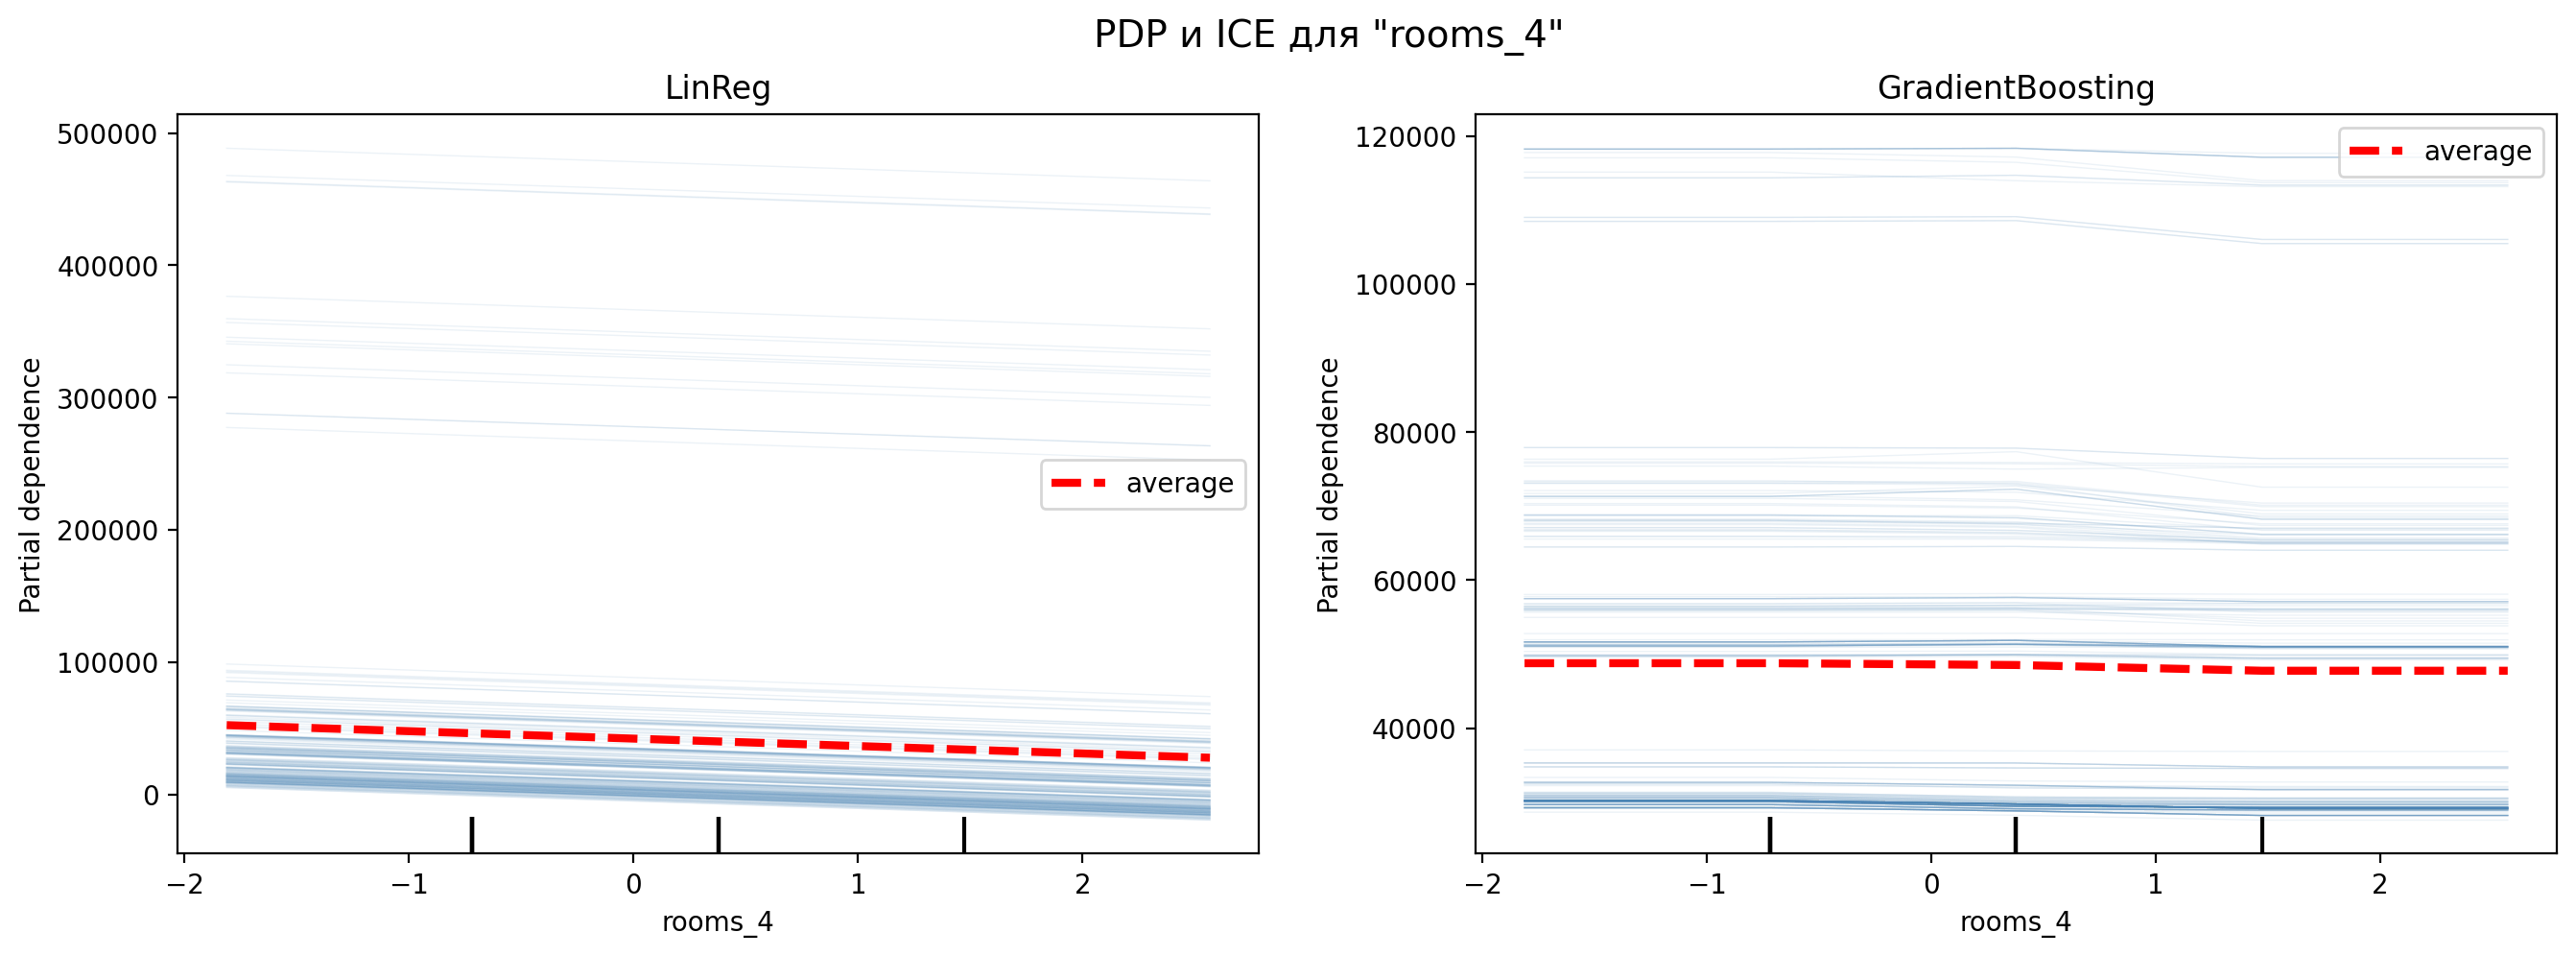

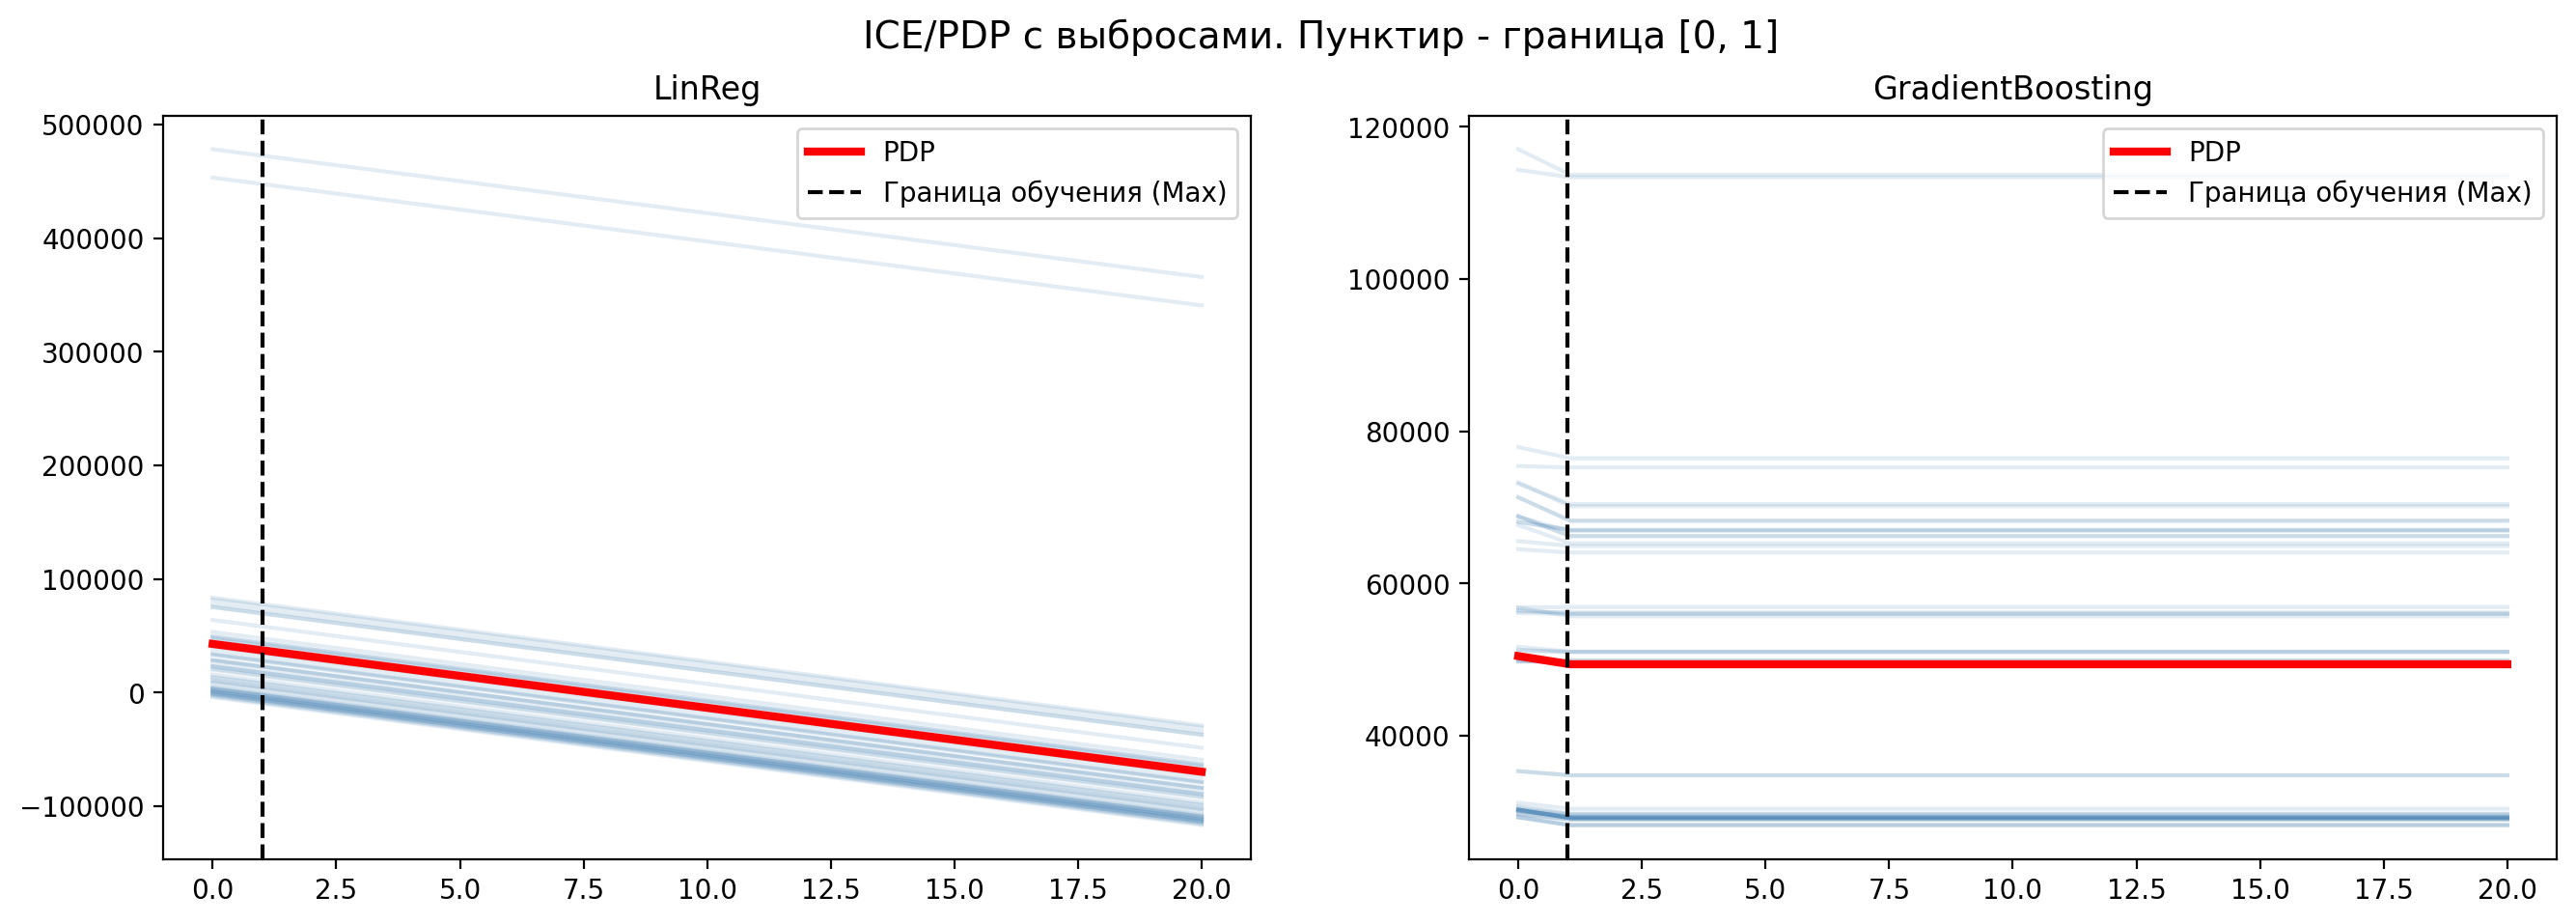

In [17]:
from sklearn.inspection import PartialDependenceDisplay

feature = 'rooms_4'
feat_idx = num_cols.index(feature)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'PDP и ICE для "{feature}"', fontsize=14)

for i, (name, model) in enumerate([('LinReg', models['LinReg']), ('GradientBoosting', models['GB'])]):
    PartialDependenceDisplay.from_estimator(
        model, X_test_scaled, [feat_idx], kind='both', ax=axes[i], feature_names=num_cols,
        ice_lines_kw={'alpha': 0.1, 'color': 'steelblue'}, pd_line_kw={'color': 'red', 'linewidth': 3}
    )
    axes[i].set_title(name)
plt.show()


feat_min, feat_max = X_train[feature].min(), X_train[feature].max()
outliers_original = [10, 30, 80]
outliers_scaled = [(v - feat_min) / (feat_max - feat_min) for v in outliers_original]

extended_grid = np.linspace(0, max(outliers_scaled), 20)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'ICE/PDP с выбросами. Пунктир - граница [0, 1]', fontsize=14)

X_sample = pd.DataFrame(X_test_scaled, columns=num_cols).sample(50, random_state=42)

for i, (name, model) in enumerate([('LinReg', models['LinReg']), ('GradientBoosting', models['GB'])]):
    ice_preds = []
    
    for val in extended_grid:
        X_temp = X_sample.copy()
        X_temp[feature] = val
        ice_preds.append(model.predict(X_temp))
        
    ice_matrix = np.array(ice_preds)
    pdp_mean = ice_matrix.mean(axis=1) 
    
    axes[i].plot(extended_grid, ice_matrix, color='steelblue', alpha=0.15)
    axes[i].plot(extended_grid, pdp_mean, color='red', linewidth=3, label='PDP')
    axes[i].axvline(1.0, color='black', linestyle='--', label='Граница обучения (Max)')
    axes[i].set_title(name)
    axes[i].legend()

plt.show()

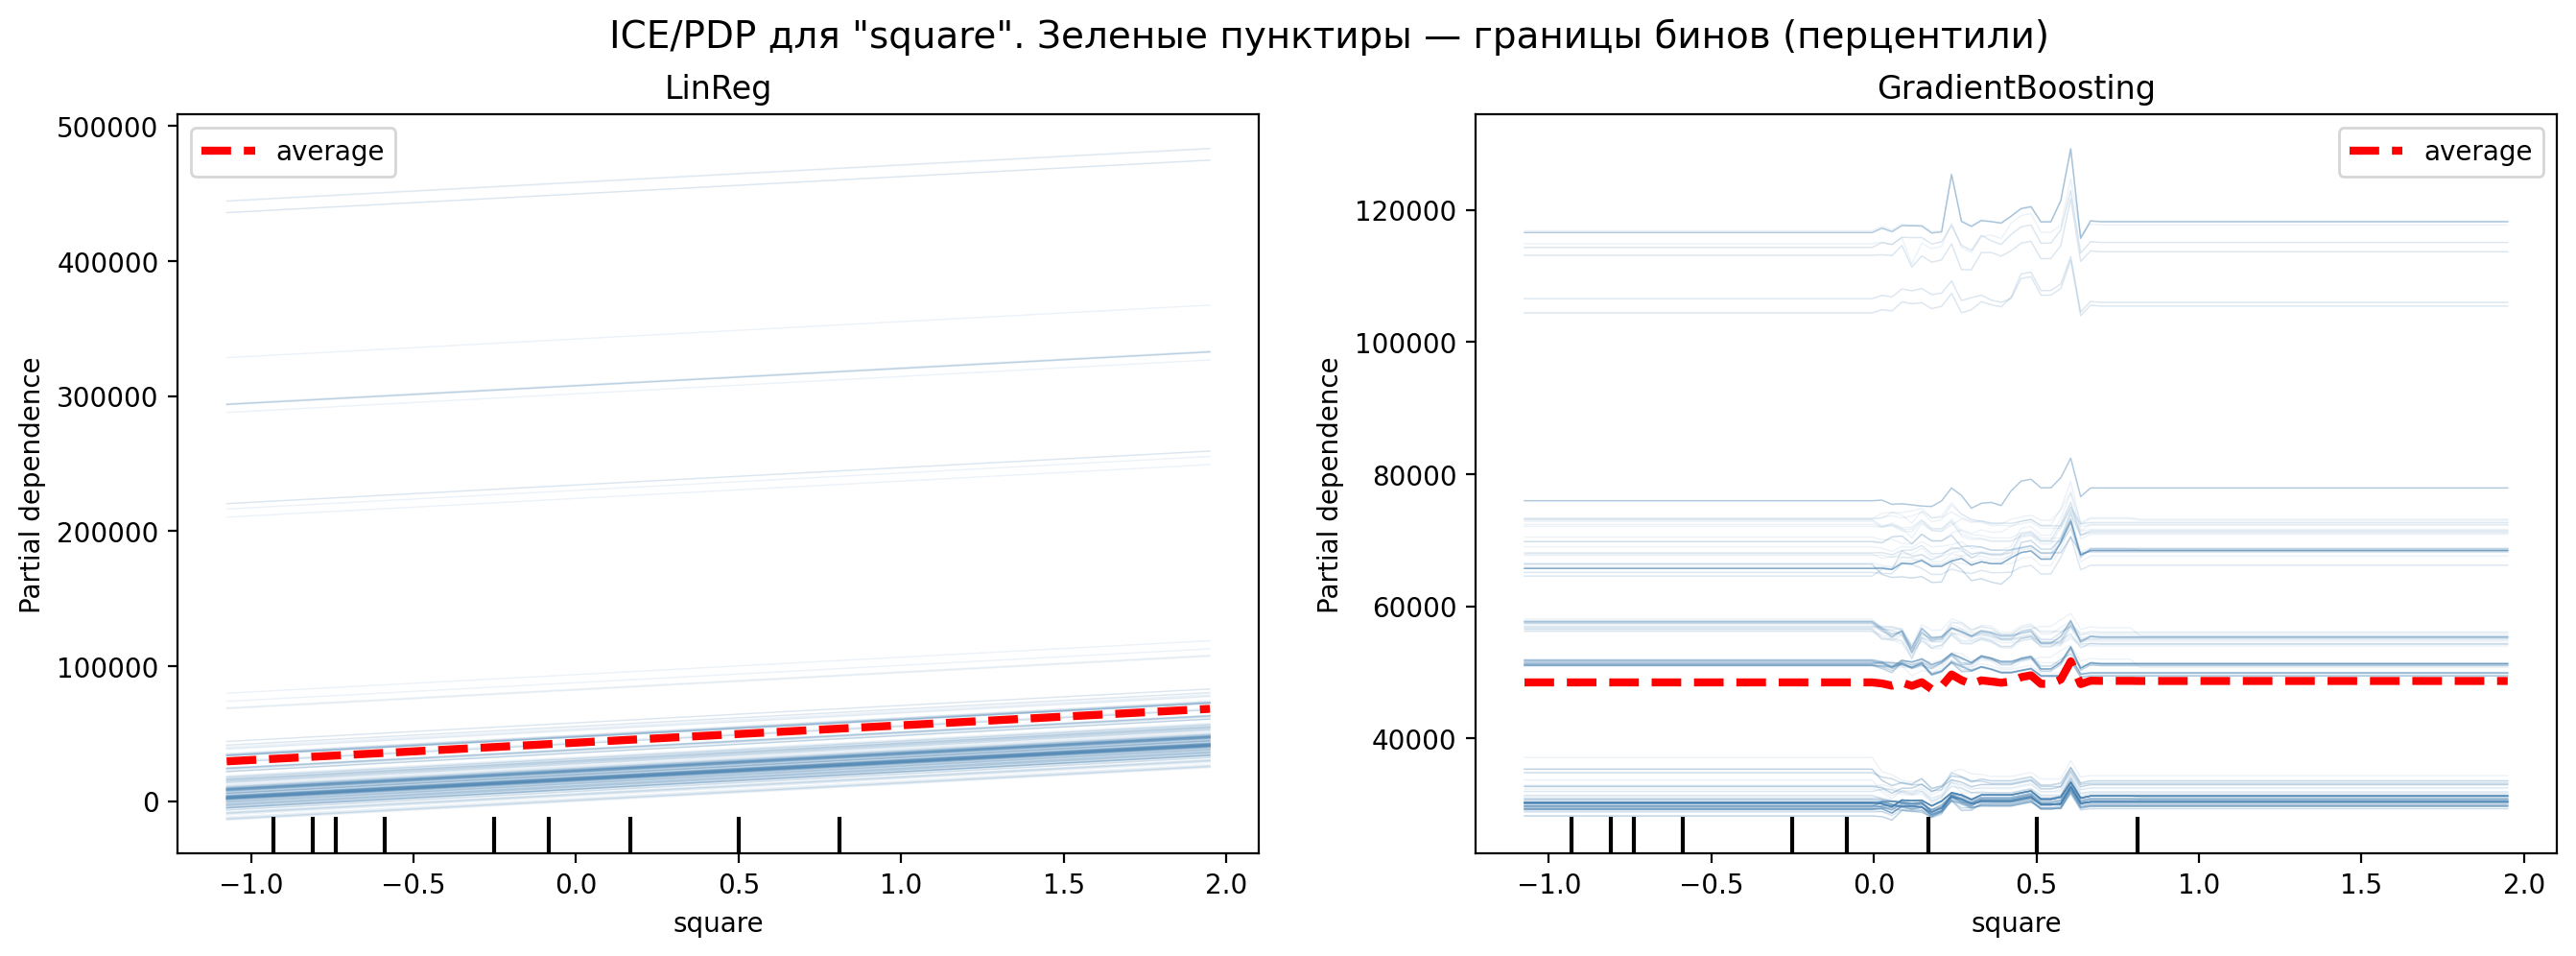

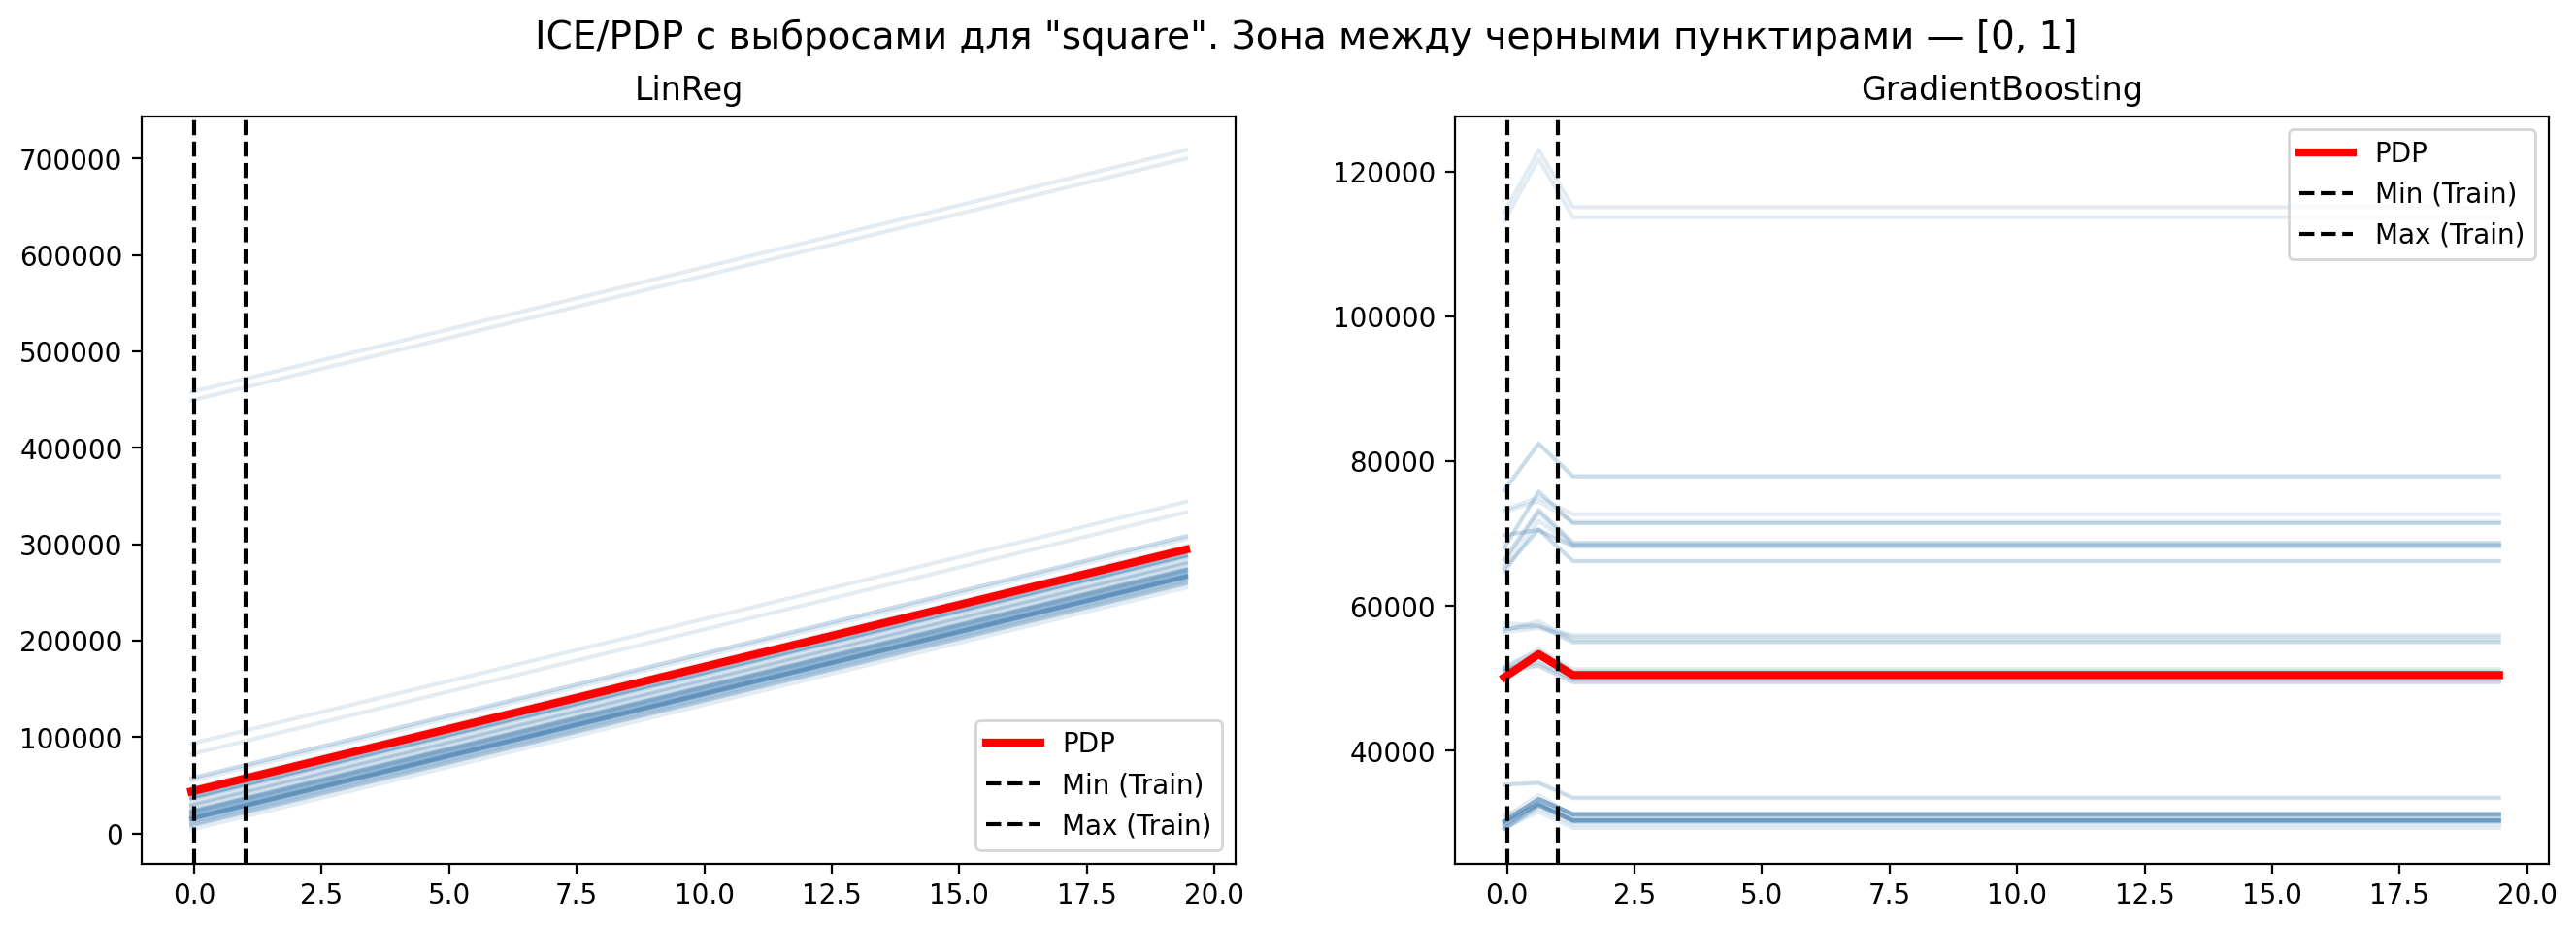

In [18]:
feature2 = 'square'
feat2_idx = num_cols.index(feature2)

bins_orig = pd.qcut(X_train[feature2], q=6, retbins=True)[1]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'ICE/PDP для "{feature2}". Зеленые пунктиры — границы бинов (перцентили)', fontsize=14)

feat2_min, feat2_max = X_train[feature2].min(), X_train[feature2].max()
bins_scaled = [(b - feat2_min) / (feat2_max - feat2_min) for b in bins_orig]

for i, (name, model) in enumerate([('LinReg', models['LinReg']), ('GradientBoosting', models['GB'])]):
    PartialDependenceDisplay.from_estimator(
        model, X_test_scaled, [feat2_idx], kind='both', ax=axes[i], feature_names=num_cols,
        ice_lines_kw={'alpha': 0.1, 'color': 'steelblue'}, pd_line_kw={'color': 'red', 'linewidth': 3}
    )
    for b_scaled in bins_scaled[1:-1]: 
        axes[i].axvline(b_scaled, color='green', linestyle=':', alpha=0.7)
    axes[i].set_title(name)

plt.show()

outliers_orig2 = [5, 6, 1000, 7000]
outliers_scaled2 = [(v - feat2_min) / (feat2_max - feat2_min) for v in outliers_orig2]

extended_grid2 = np.linspace(min(outliers_scaled2), max(outliers_scaled2), 30)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'ICE/PDP с выбросами для "{feature2}". Зона между черными пунктирами — [0, 1]', fontsize=14)

X_sample2 = pd.DataFrame(X_test_scaled, columns=num_cols).sample(50, random_state=42)

for i, (name, model) in enumerate([('LinReg', models['LinReg']), ('GradientBoosting', models['GB'])]):
    ice_preds2 = []
    for val in extended_grid2:
        X_temp = X_sample2.copy()
        X_temp[feature2] = val
        ice_preds2.append(model.predict(X_temp))
        
    ice_matrix2 = np.array(ice_preds2)
    pdp_mean2 = ice_matrix2.mean(axis=1)
    
    axes[i].plot(extended_grid2, ice_matrix2, color='steelblue', alpha=0.15)
    axes[i].plot(extended_grid2, pdp_mean2, color='red', linewidth=3, label='PDP')
    
    axes[i].axvline(0.0, color='black', linestyle='--', label='Min (Train)')
    axes[i].axvline(1.0, color='black', linestyle='--', label='Max (Train)')
    
    axes[i].set_title(name)
    axes[i].legend()

plt.show()

## Задание 3. 1 балл
Выберите 20 объектов из тестовой выборки.
Для каждого объекта из выбранного набора построим траекторию изменения предсказания модели при постепенном изменении значения признака от его текущего значения к базовому значению (медиана или среднее по обучающей выборке).

**Алгоритм:**
1. Выбрать объект $x_i$ из тестовой выборки
2. Для интересующего признака $j$:
   - Текущее значение: $x_{i,j}$
   - Базовое значение: $x_{base,j}$ (медиана или среднее по обучающей выборке)
3. Построить линейную интерполяцию между $x_{i,j}$ и $x_{base,j}$ с $n$ шагами
4. Для каждого шага интерполяции:
   - Заменить значение признака $j$ в объекте $x_i$ на значение из интерполяции
   - Вычислить предсказание модели для модифицированного объекта
5. Построить график траектории


Задание 3.1 (*) 1 балл: проанализируйте также еще один признак

Признак 'location_parking_cnt', Медиана = 91.00


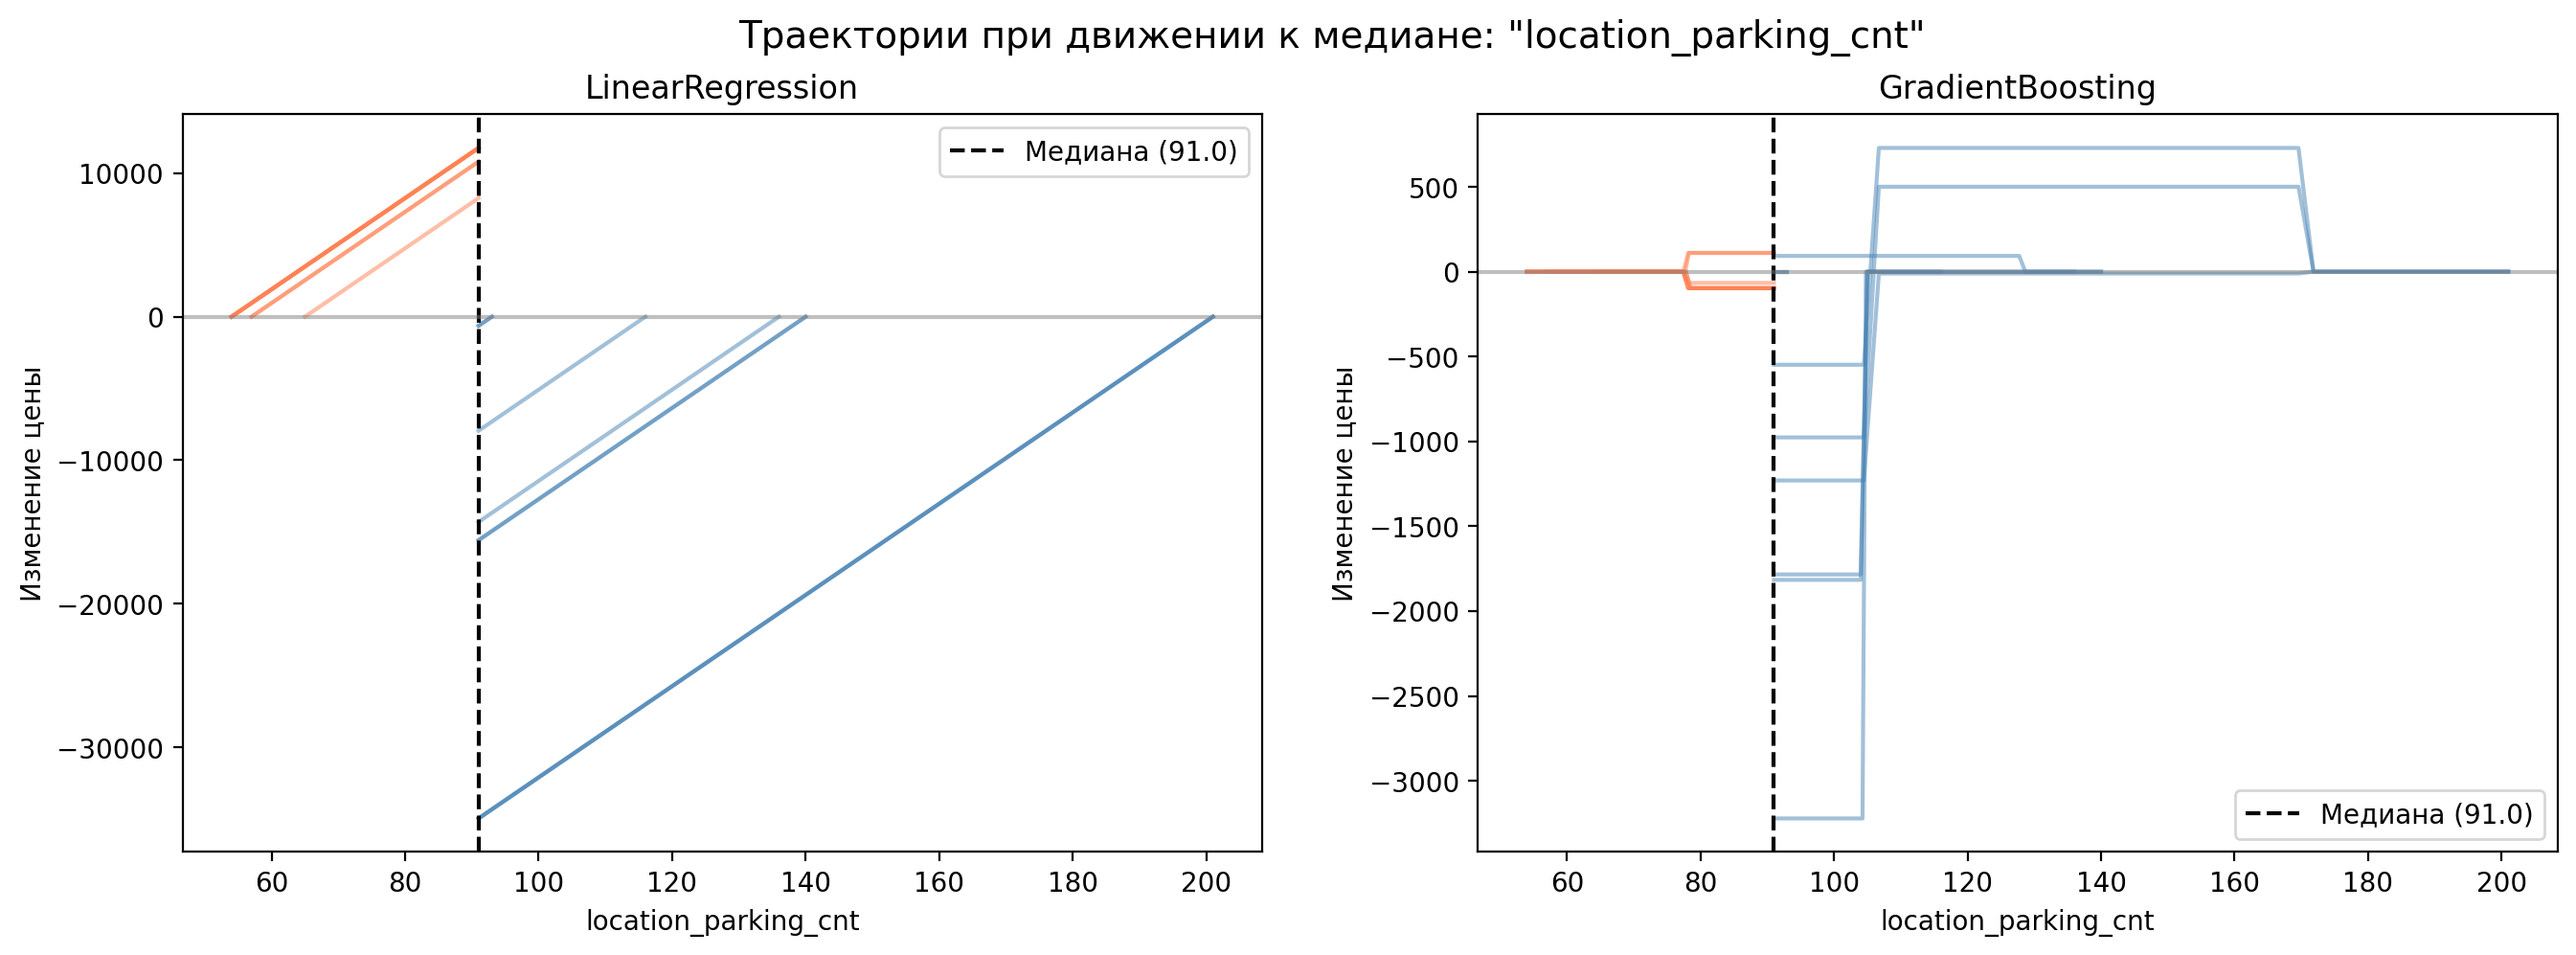

Признак 'square', Медиана = 58.05


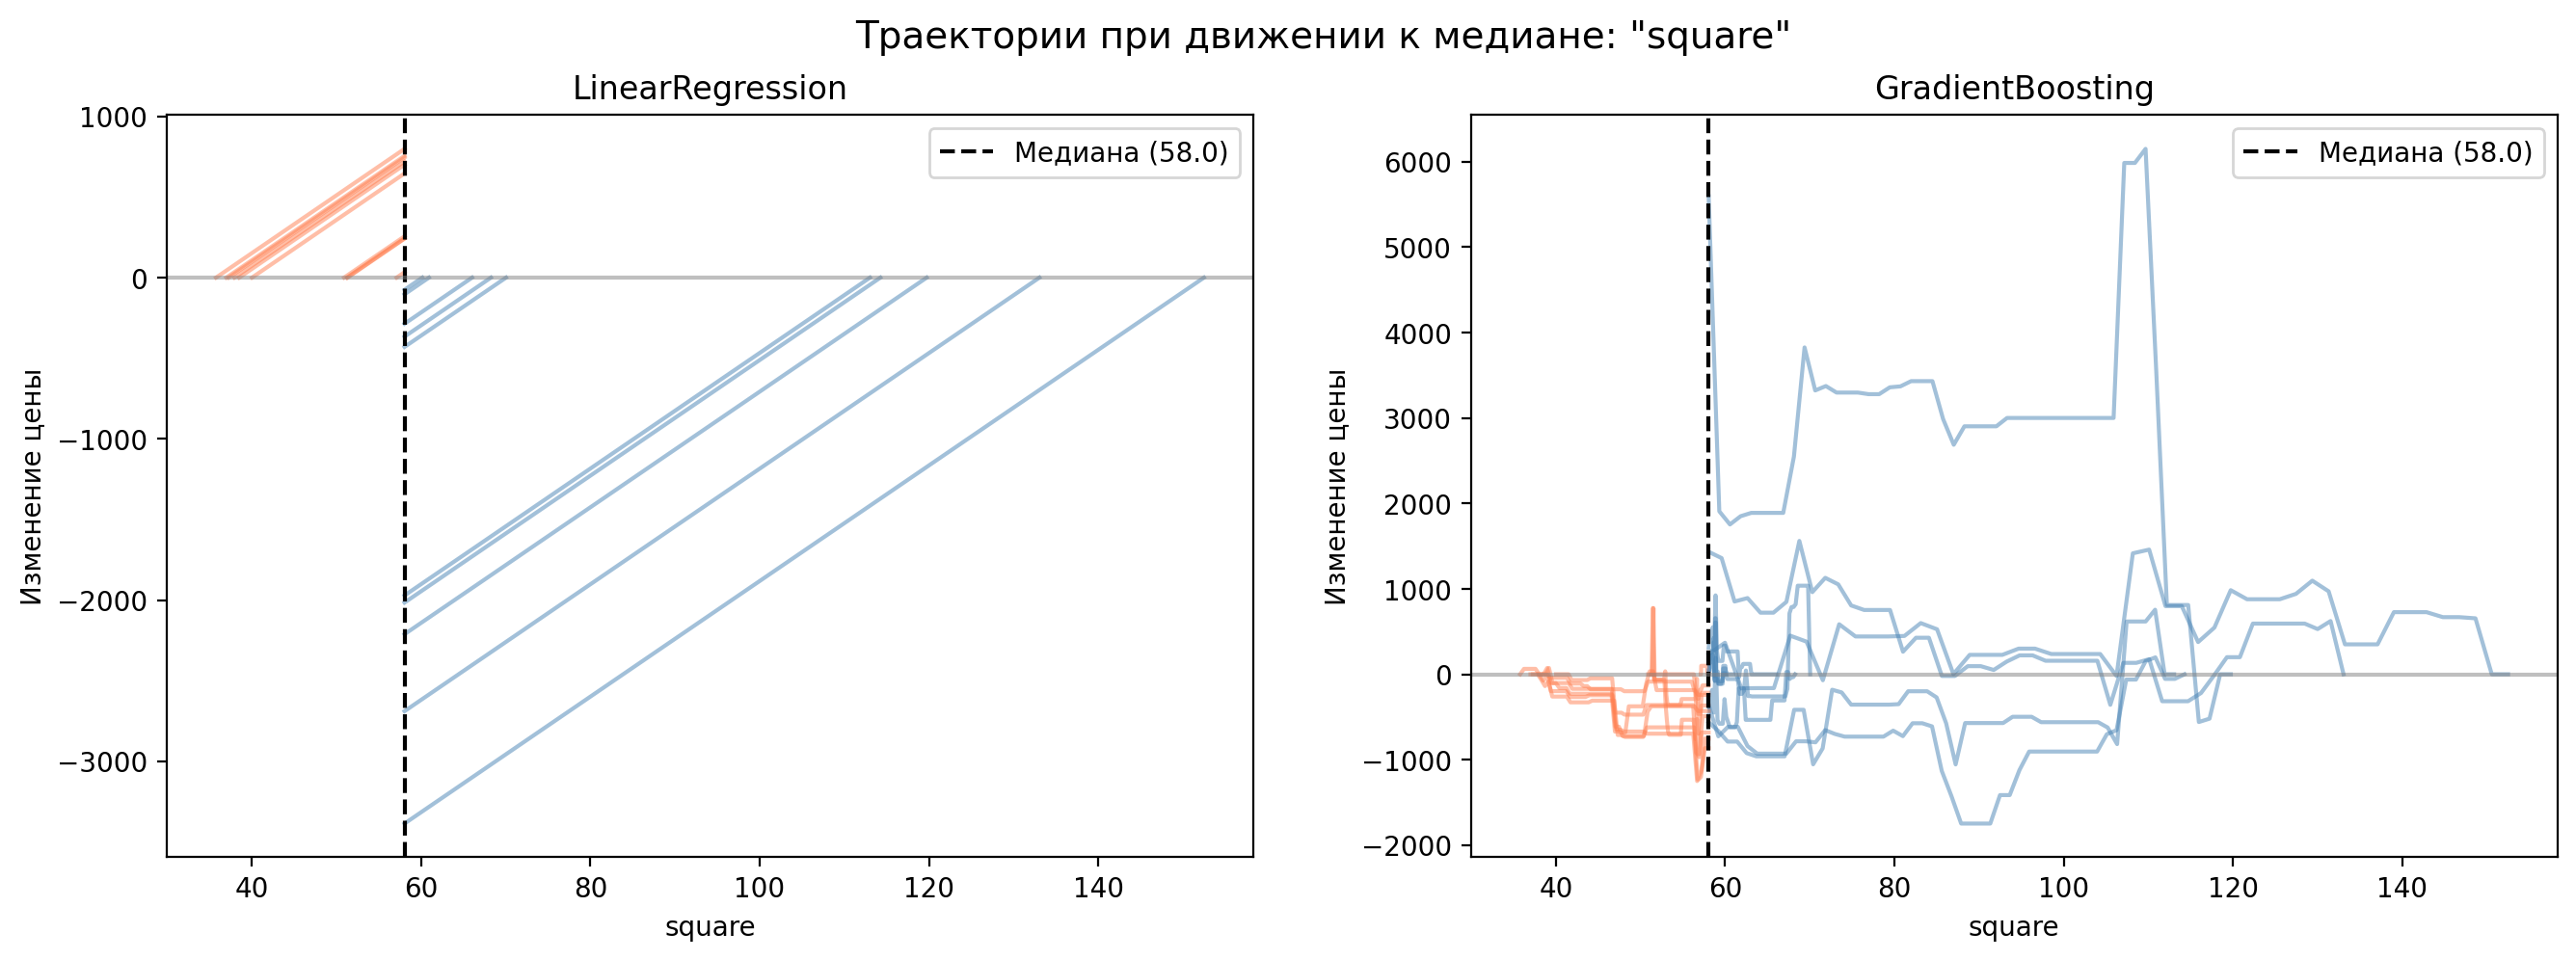

In [26]:
np.random.seed(42)
X_sample = X_test.sample(20)

lr_model = LinearRegression().fit(X_train, y_train)
gb_model = GradientBoostingRegressor(max_depth=5, random_state=42).fit(X_train, y_train)

models_traj = {
    'LinearRegression': lr_model, 
    'GradientBoosting': gb_model
}

def plot_fast_trajectories(feature, models_dict, X_tr, X_samp, n_steps=50):
    base_val = X_tr[feature].median() #Базовое значение
    print(f"Признак '{feature}', Медиана = {base_val:.2f}")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'Траектории при движении к медиане: "{feature}"', fontsize=14)

    for ax, (name, model) in zip(axes, models_dict.items()):
        for i in range(len(X_samp)):
            obj = X_samp.iloc[i:i+1].copy()
            curr_val = obj[feature].values[0]#Текущее значение
            steps = np.linspace(curr_val, base_val, n_steps)#строим точки (линейная интерполяця)
            df_steps = pd.concat([obj]*n_steps, ignore_index=True)#копируем объект n раз
            df_steps[feature] = steps #заменяем значения
            preds = model.predict(df_steps)#вычисляем предсказание модели для модифицированных объектов
            
            color = 'steelblue' if curr_val > base_val else 'coral'
            ax.plot(steps, preds - preds[0], alpha=0.5, color=color)

        ax.axvline(base_val, color='black', linestyle='--', label=f'Медиана ({base_val:.1f})')
        ax.axhline(0, color='gray', alpha=0.5)
        ax.set_title(name)
        ax.set_xlabel(feature)
        ax.set_ylabel('Изменение цены')
        ax.legend()

    plt.show()

plot_fast_trajectories('location_parking_cnt', models_traj, X_train, X_sample) #location_buildings_cnt
plot_fast_trajectories('square', models_traj, X_train, X_sample)

## Задание 4 (1 балл). ALE
Постройте ALE по обеим моделям, используя pyALE. Подберите размер сетки так, чтобы получить доверительные интервалы. Проанализируйте полученный график. Каковы получились доверительные интервалы? Почему они различны для моделей?

P.s. Сетку значений стройте для исходного признака.

PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


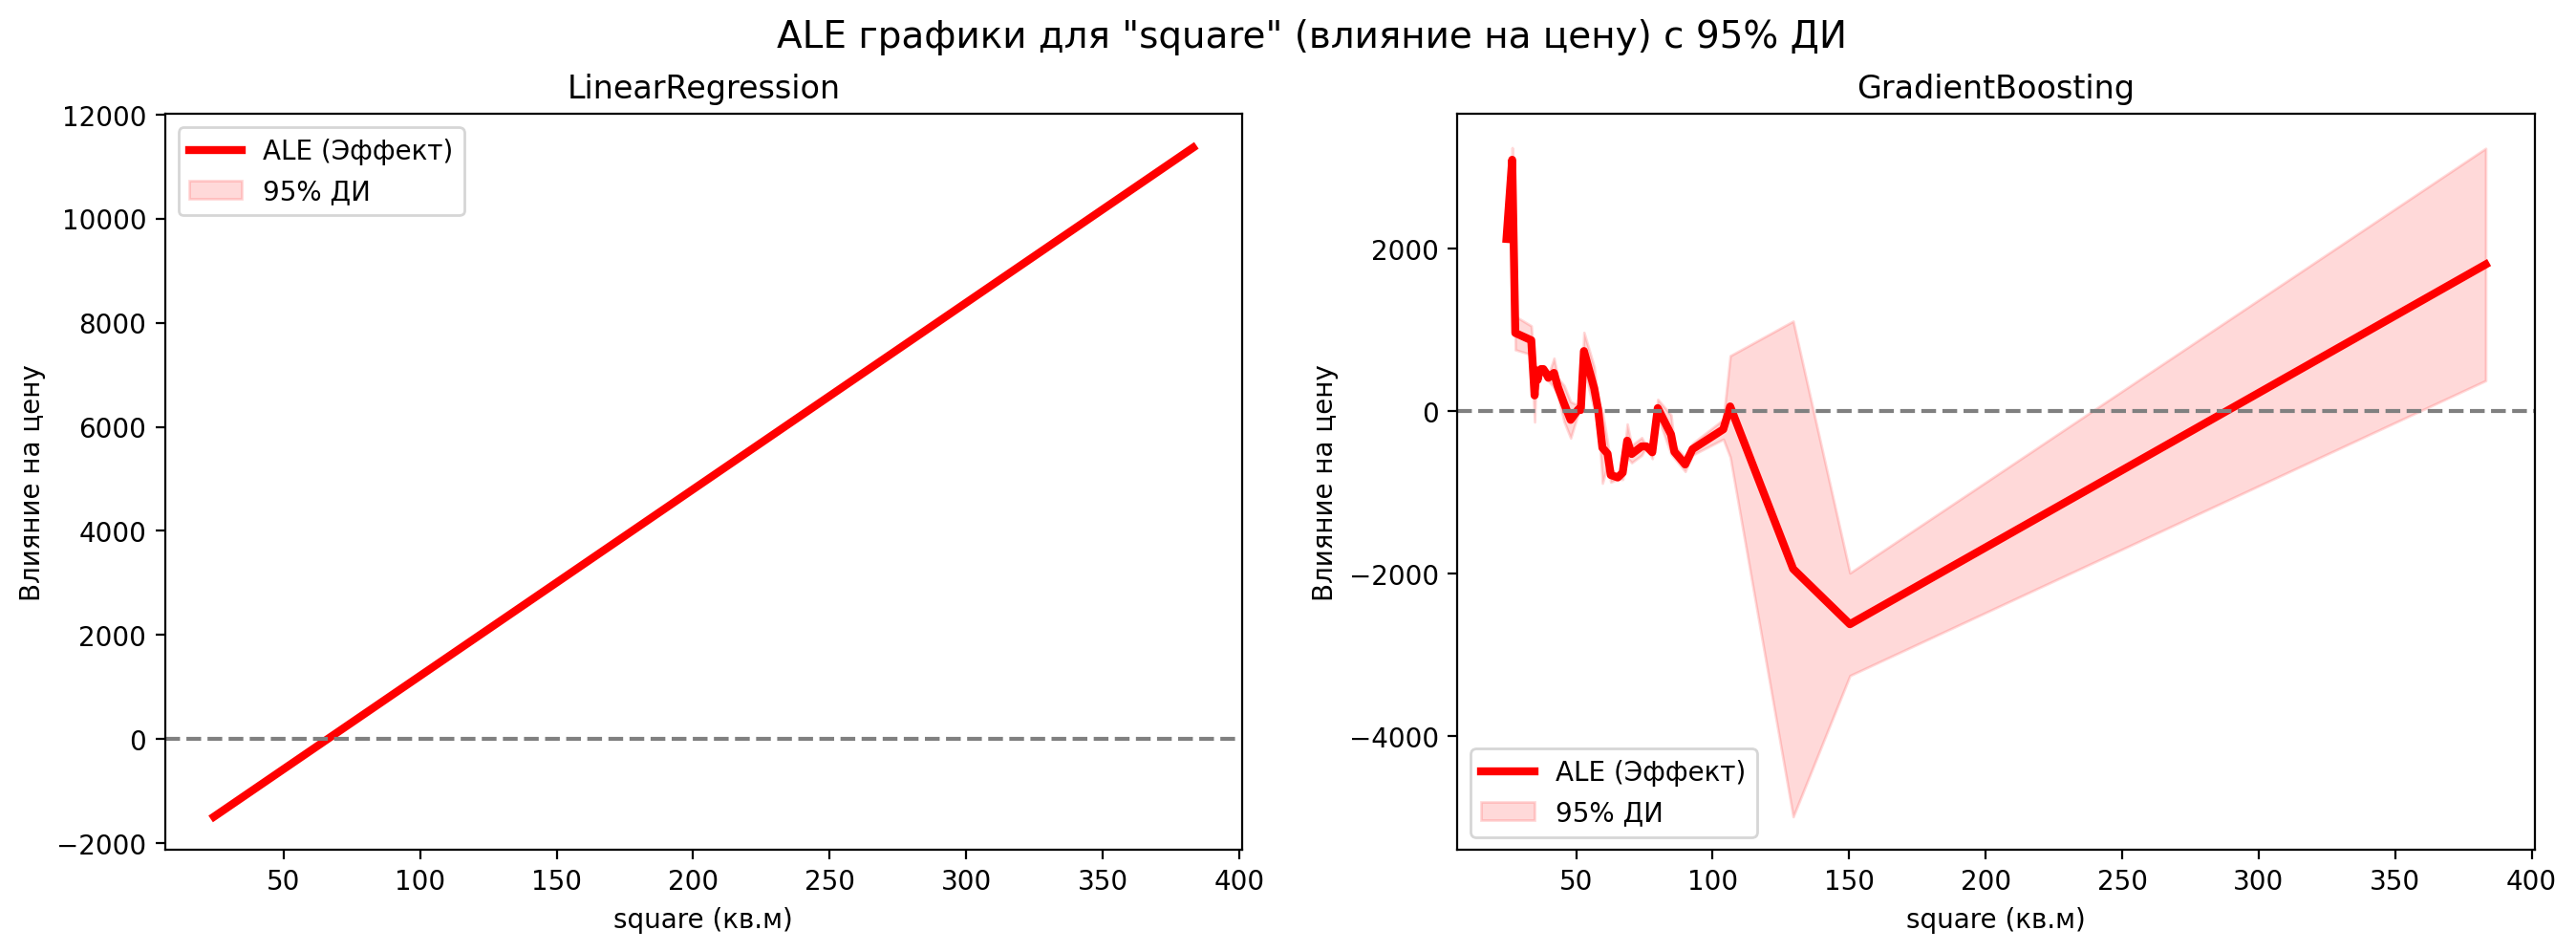

In [ ]:
from PyALE import ale
import matplotlib.pyplot as plt

feature = 'square'

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'ALE графики для "{feature}" (влияние на цену) с 95% ДИ', fontsize=14)

for ax, (name, model) in zip(axes, models_traj.items()):
    ale_df = ale(X=X_train, model=model, feature=[feature], grid_size=40, include_CI=True, C=0.95, plot=False)
    ax.plot(ale_df.index, ale_df['eff'], color='red', lw=3, label='ALE (Эффект)')
    ax.fill_between(ale_df.index, ale_df['lowerCI_95%'], ale_df['upperCI_95%'], 
                    color='red', alpha=0.15, label='95% ДИ')
    
    ax.set_title(name)
    ax.set_xlabel(f'{feature} (кв.м)')
    ax.set_ylabel('Влияние на цену')
    ax.axhline(0, color='gray', linestyle='--')
    ax.legend()

plt.show()

## Задание 5:  Permutation Importance (2 балла)
Постройте Permutation importances по обеим моделям, используя sklearn.

Поэкспериментируйте с числом перестановок.

Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов?



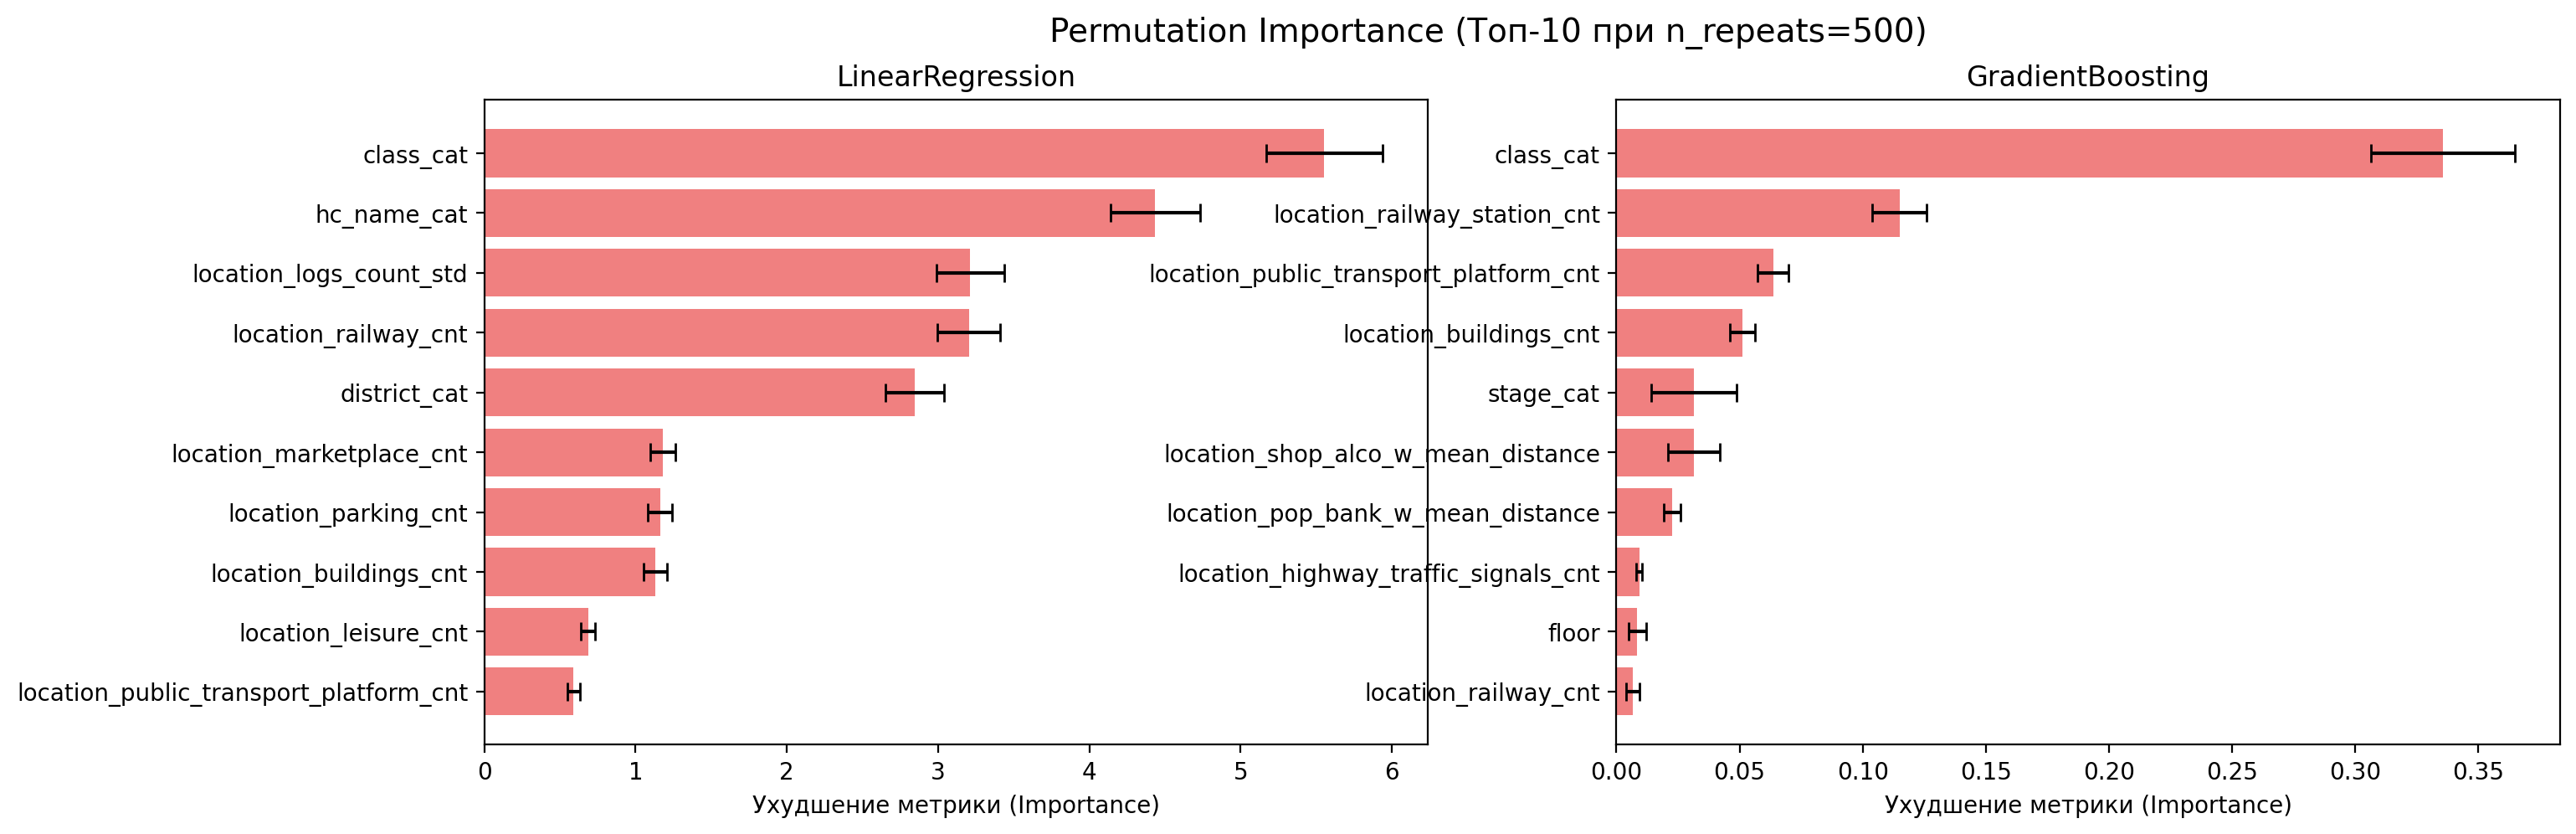

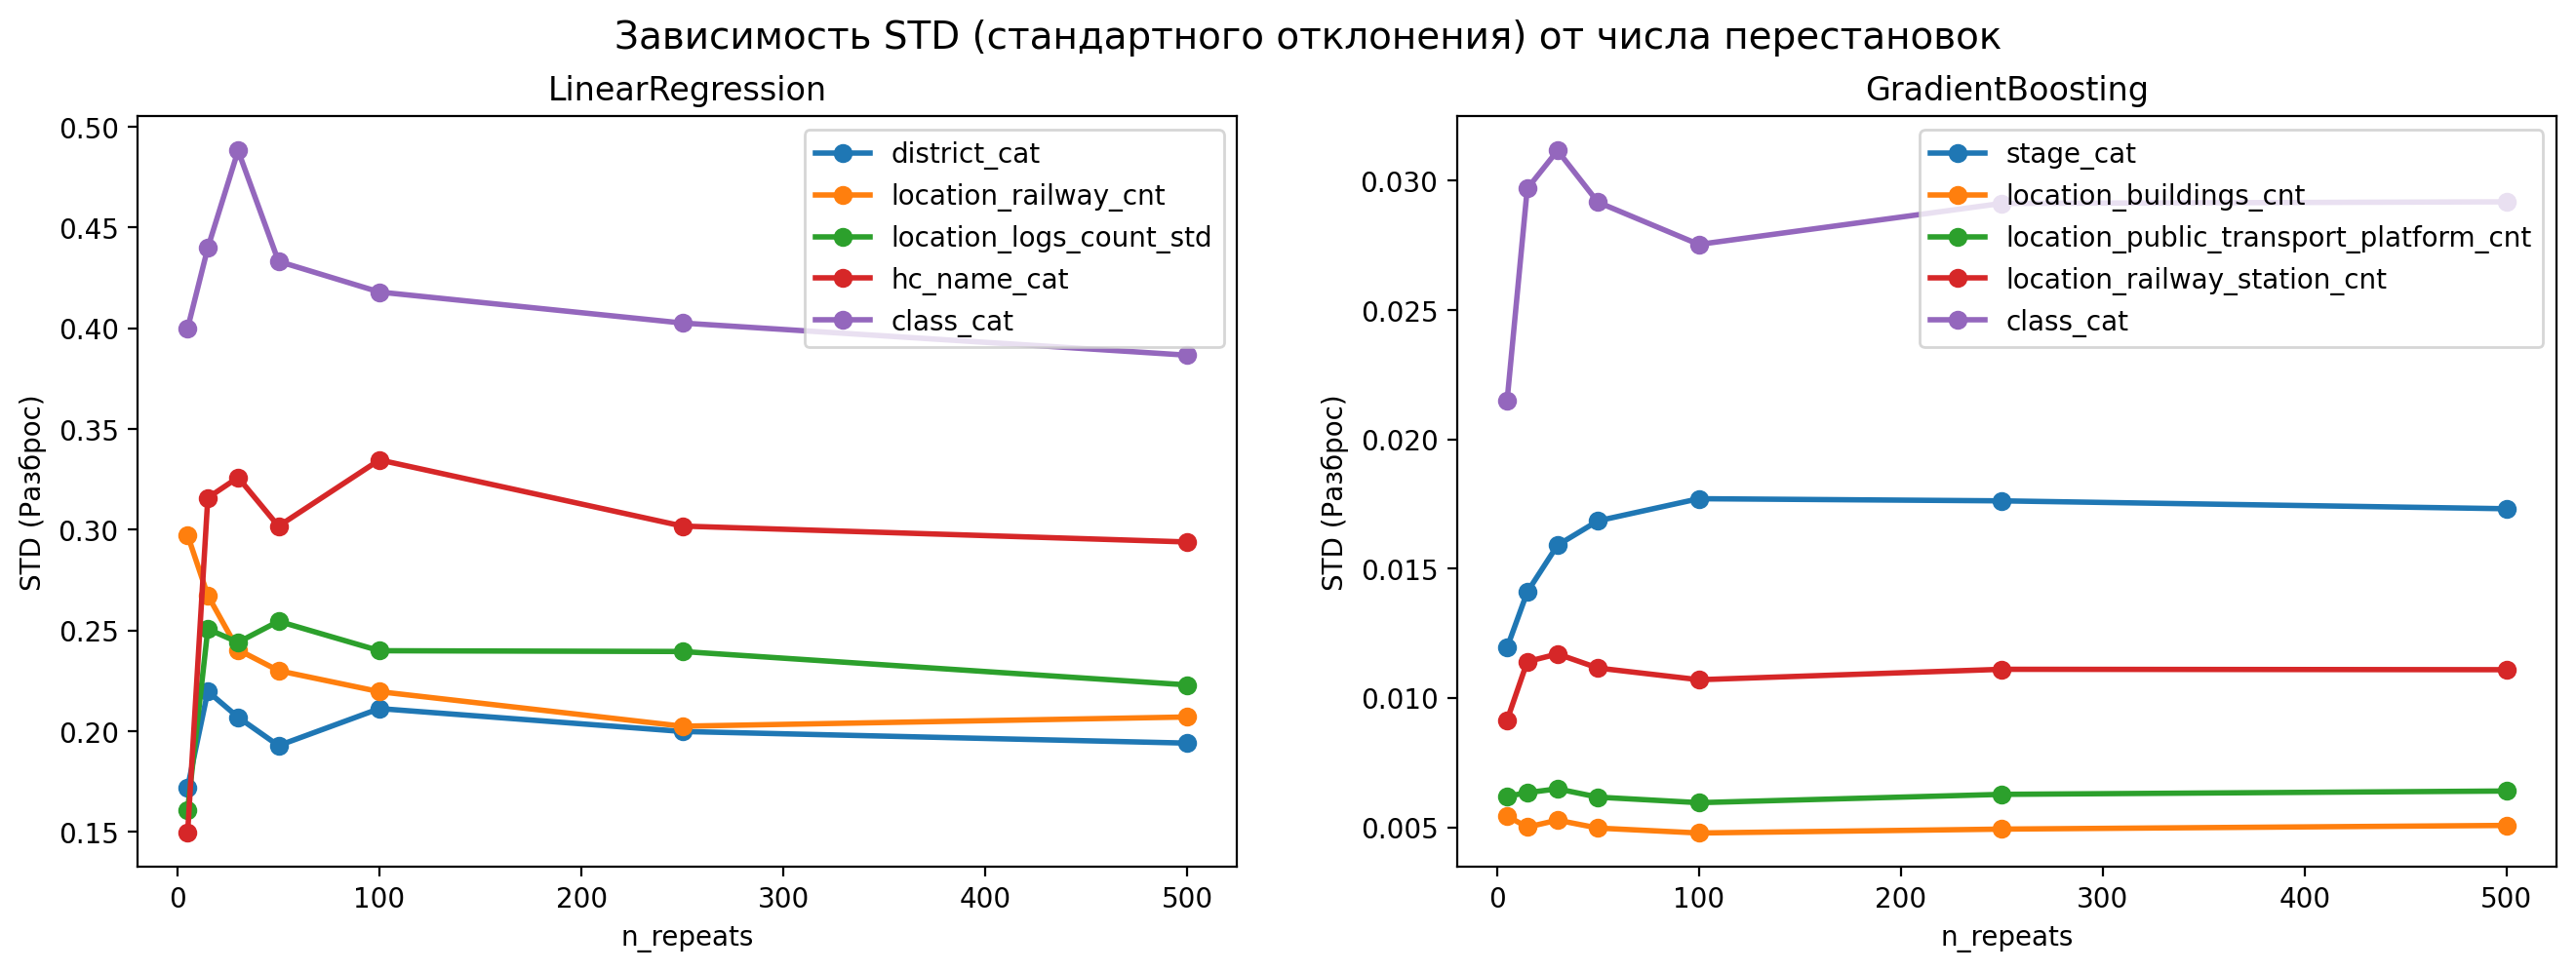

In [31]:
max_repeats = 500
repeats_list = [5, 15, 30, 50, 100, 250, 500]
perm_results = {}

for name, model in models_traj.items():
    n_jobs=-1 
    perm_results[name] = permutation_importance(model, X_test, y_test, n_repeats=max_repeats, random_state=42, n_jobs=-1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'Permutation Importance (Топ-10 при n_repeats={max_repeats})', fontsize=14)

for ax, name in zip(axes, models_traj.keys()):
    res = perm_results[name]
    
    df_imp = pd.DataFrame({'mean': res.importances_mean, 'std': res.importances_std}, index=X_test.columns)
    df_imp = df_imp.sort_values('mean').tail(10) 
    
    ax.barh(df_imp.index, df_imp['mean'], xerr=df_imp['std'], capsize=4, color='lightcoral')
    ax.set_title(name)
    ax.set_xlabel('Ухудшение метрики (Importance)')

plt.show()
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Зависимость STD (стандартного отклонения) от числа перестановок', fontsize=14)

for ax, name in zip(axes, models_traj.keys()):
    res = perm_results[name]
    top5_idx = np.argsort(res.importances_mean)[-5:]
    
    for idx in top5_idx:
        feat_name = X_test.columns[idx]
        std_history = []
        
        for n in repeats_list:
            std = np.std(res.importances[idx, :n])
            std_history.append(std)
            
        ax.plot(repeats_list, std_history, marker='o', lw=2, label=feat_name)
        
    ax.set_title(name)
    ax.set_xlabel('n_repeats')
    ax.set_ylabel('STD (Разброс)')
    ax.legend()

plt.show()

## Задание 5: Feature Importance (2 балла)
Пусть важность - это MAPE для тестовых данных. Проведите анализ только для бустинга

Идея перестановочной важности представляет собой частный случай важности при помощи внесения возмущений в признак. Примеры возмущений:
1) внесение случайного шума
2) зануление признака
3) сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели 

Примем за базовое значение (${base}$)медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:
$x_j^\beta = (1- \beta)x_j + \beta {base}$

Реализуйте это возмущение. Как меняются важности при разных $\beta$?

Постройте графики важности и сравните важности с permutation importance. Используйте только числовые признаки. При этом медиану стоит считать на тренировочном наборе, а важность как разницу MAPE на тестовой выборке. Чем больше разница, тем важнее признак. 


Сравните результаты методов. Какие признаки наиболее важны? Есть ли различия между методами? В чём могут быть причины различий?

Базовый MAPE: 3.65%



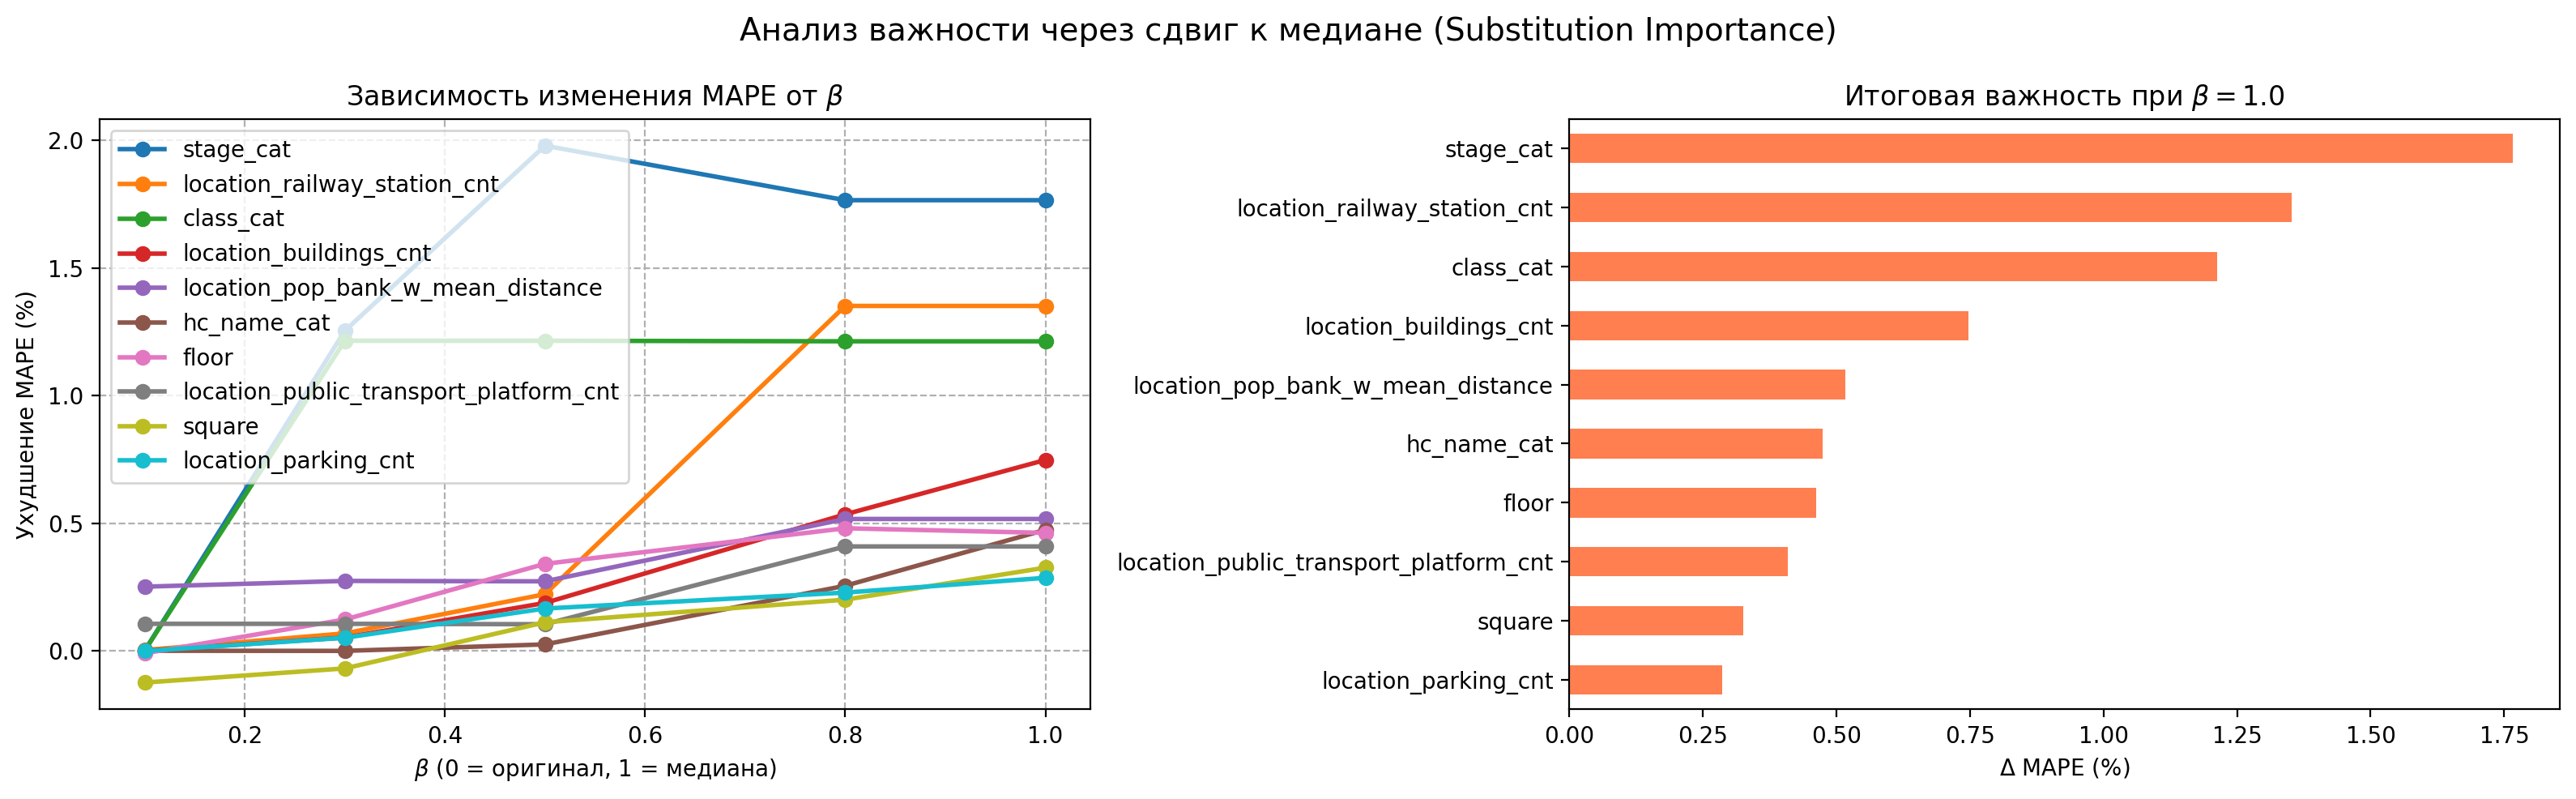

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

gb_model = models_traj['GradientBoosting']
base_mape = mean_absolute_percentage_error(y_test, gb_model.predict(X_test)) * 100
print(f"Базовый MAPE: {base_mape:.2f}%\n")

betas = [0.1, 0.3, 0.5, 0.8, 1.0]
importance_results = {}

#сдвиг признаков к медиане
for feature in num_cols:
    median_val = X_train[feature].median()
    feature_imp = []
    
    for beta in betas:
        X_perturbed = X_test.assign(**{feature: (1 - beta) * X_test[feature] + beta * median_val})
        new_mape = mean_absolute_percentage_error(y_test, gb_model.predict(X_perturbed)) * 100
        feature_imp.append(new_mape - base_mape)
        
    importance_results[feature] = feature_imp

df_imp = pd.DataFrame.from_dict(importance_results, orient='index', columns=betas)
df_imp = df_imp.sort_values(by=1.0, ascending=False).head(10) 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Анализ важности через сдвиг к медиане (Substitution Importance)', fontsize=14)

#Траектория изменения важности от бета
df_imp.T.plot(marker='o', lw=2, ax=ax1, cmap='tab10') 
ax1.set_title('Зависимость изменения MAPE от $\\beta$')
ax1.set_xlabel('$\\beta$ (0 = оригинал, 1 = медиана)')
ax1.set_ylabel('Ухудшение MAPE (%)')
ax1.grid(True, linestyle='--')

#Итоговая важность при Бета = 1.0
df_imp[1.0].sort_values().plot(kind='barh', ax=ax2, color='coral')
ax2.set_title('Итоговая важность при $\\beta = 1.0$')
ax2.set_xlabel('$\\Delta$ MAPE (%)')



plt.tight_layout()

plt.show()


Чем больще бета тем сильнее растет ошибка, для менее важных признаков ошибка растет медленее чем для важных. В сравнении с перемешиванием - в перемешивании ошибка резко возрастает а потом сглаживается, в сдвиге к медиане монотонно возрастает

#  Задание 6. 2 балла. LIME.
Постройте интерпретацию признаков для нескольких примеров с помощью LIME. Можете использовать 
Оцените устойчивость реализации. Как влияет на коэффициенты количество сгенерированных точек? А выбор признаков (lasso/добавление фичей по порядку). А выбор ядра?

(*) Вы получите на 2 балла больше, если используете свою реализацию из задания семинарского ноутбука. В таком случае не забудьте добавить тесты для своей реализации. 



In [ ]:
LIME объясняет одно конкретное предсказание любой модели, локально аппроксимируя её простой интерпретируемой моделью (обычно линейной регрессией).


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances

class LIME:
    def __init__(self, X_train, kernel_width=None):
        self.X_train = X_train.values if isinstance(X_train, pd.DataFrame) else X_train
        self.feature_names = X_train.columns if hasattr(X_train, 'columns') else np.arange(self.X_train.shape[1])
        self.scaler = StandardScaler().fit(self.X_train)#стандартизатор обучаем на тесте, чтобы генерировать шум и вычислять расстояния
        
        #ширина ядра - параметр, контролирующий расстояние на котором считаем соседей близкими, по умолчанию - корень из количества признаков * 3/4
        self.kernel_width = kernel_width or np.sqrt(self.X_train.shape[1]) * 0.75
        
    def _kernel(self, distances): #функция гаусса, превращает "расстояние" в вес от 0 до 1, чем больше расстояние тем меньше вес соседа
        return np.exp(-(distances ** 2) / (self.kernel_width ** 2)) 
    
    def explain_instance(self, x_instance, predict_fn, num_samples=1000, model_reg=Ridge(alpha=1.0)):
        x_inst = x_instance.values if isinstance(x_instance, pd.Series) else x_instance
        #генерируем соседей, рандомно, дисперсия шума - стандартное отклонение каждого признака из теста, так шум правдоподобен реальным записям
        noise = np.random.normal(0, self.scaler.scale_, size=(num_samples, len(x_inst)))
        X_surrogate = x_inst + noise#получаем соседей прибавляя шум к оригиналу 
        X_surrogate[0] = x_inst #первой точкой оставляем оригинал
        
        y_surrogate = predict_fn(X_surrogate)#получаем предсказания которые будем объяснять
        
        X_surrogate_scaled = self.scaler.transform(X_surrogate)
        x_inst_scaled = self.scaler.transform(x_inst.reshape(1, -1))#масштабируем оригинал и соседей 
        
        distances = pairwise_distances(X_surrogate_scaled, x_inst_scaled).flatten()#считаем расстояния до соседей, получаем из них веса
        weights = self._kernel(distances)
        
        model_reg.fit(X_surrogate_scaled, y_surrogate, sample_weight=weights)#обучаем регрессию на взвешенных соседях
        
        coefs_original = model_reg.coef_ / self.scaler.scale_
        return pd.Series(coefs_original, index=self.feature_names).sort_values() #возвращаем кожффициенты в реальный масштаб


def test_lime():
    X_dummy = pd.DataFrame(np.random.randn(100, 3), columns=['A', 'B', 'C'])
    predict_fn = lambda x: x[:, 0] * 2 + x[:, 1] * 0.5 # A=2, B=0.5, C=0
    
    lime = LIME(X_dummy)
    coefs = lime.explain_instance(X_dummy.iloc[0], predict_fn, num_samples=500)
    
    assert np.isclose(coefs['A'], 2.0, atol=0.2), "Ошибка в признаке A"
    assert np.isclose(coefs['B'], 0.5, atol=0.2), "Ошибка в признаке B"
    assert np.isclose(coefs['C'], 0.0, atol=0.2), "Ошибка в признаке C"
    print("ok")

test_lime()

ok


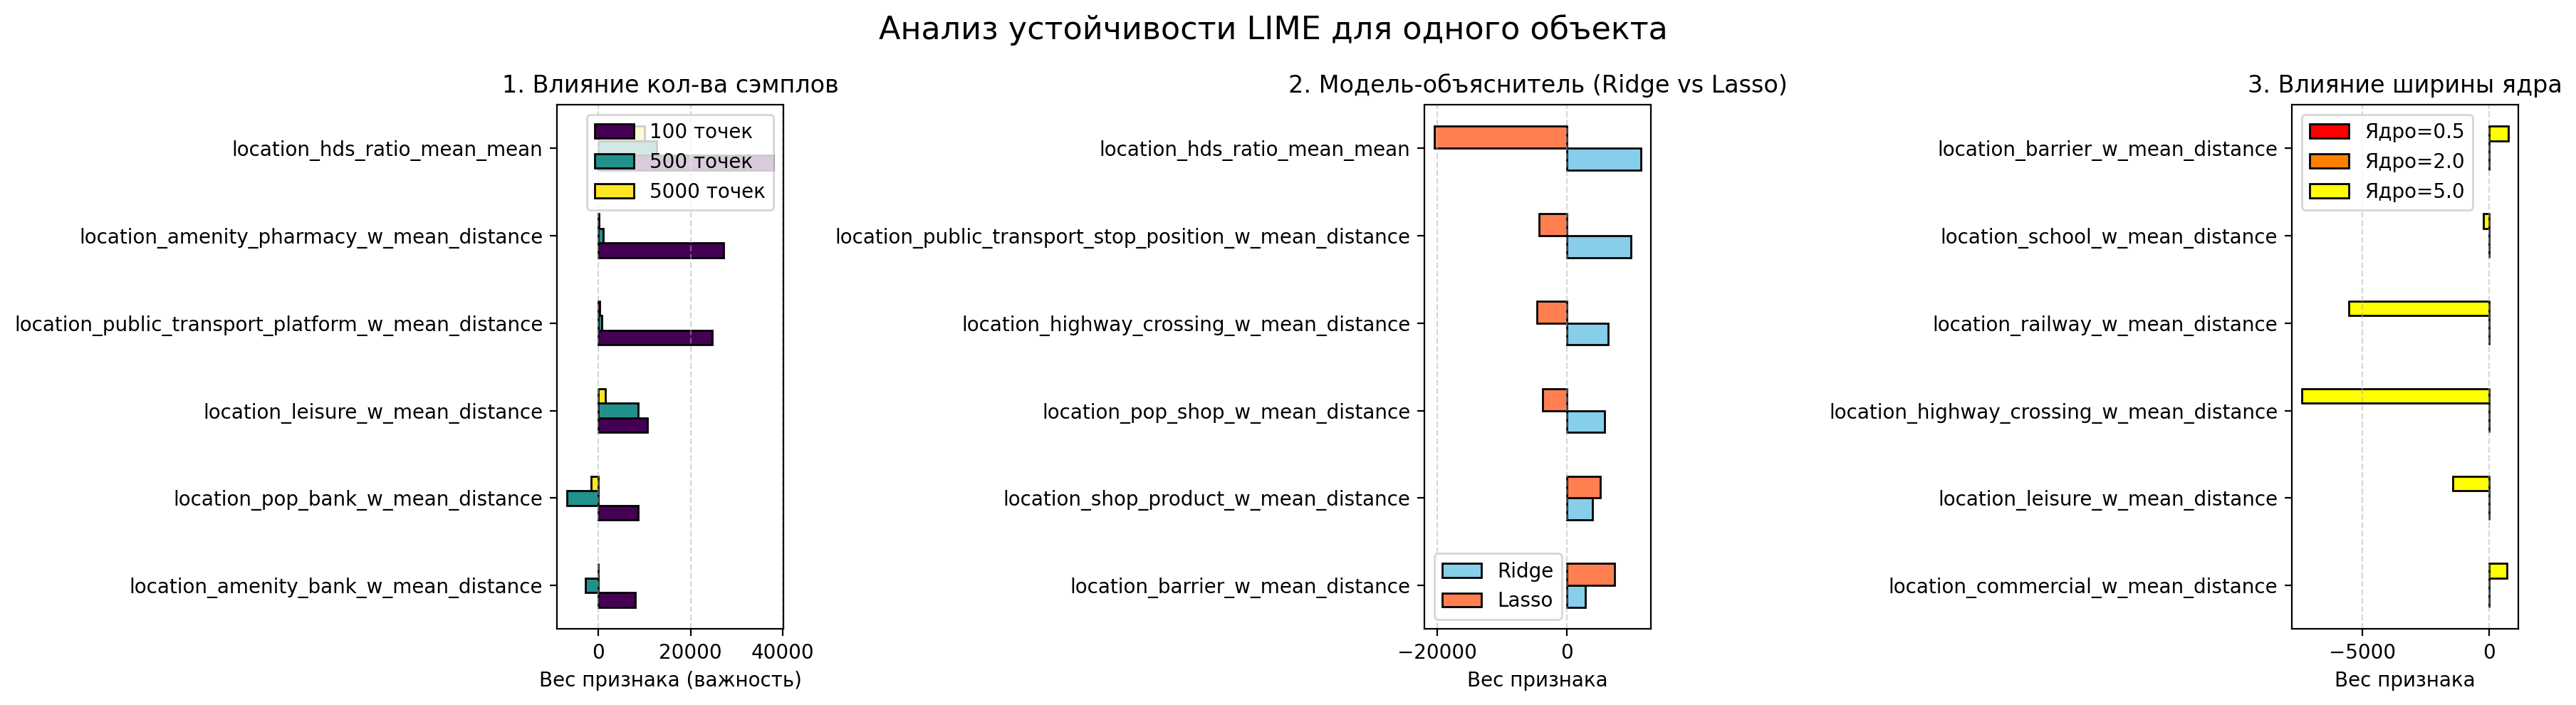

In [49]:
plt.style.use('default')
gb_model = GradientBoostingRegressor(max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)

gb_predict_fn = gb_model.predict #функция суррогатная берем ГБ

np.random.seed(42)
x_test_instance = X_test.iloc[0]

explainer = LIME(X_train)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Анализ устойчивости LIME для одного объекта', fontsize=16)

samples_list = [100, 500, 5000]
df_samples = pd.DataFrame()
for n in samples_list:
    df_samples[f'{n} точек'] = explainer.explain_instance(x_test_instance, gb_predict_fn, num_samples=n)

df_samples.tail(6).plot(kind='barh', ax=axes[0], colormap='viridis', edgecolor='black')
axes[0].set_title('1. Влияние кол-ва сэмплов')
axes[0].set_xlabel('Вес признака (важность)')

df_models = pd.DataFrame()
df_models['Ridge'] = explainer.explain_instance(x_test_instance, gb_predict_fn, model_reg=Ridge(alpha=1.0))
df_models['Lasso'] = explainer.explain_instance(x_test_instance, gb_predict_fn, model_reg=Lasso(alpha=0.1))

df_models = df_models.sort_values(by='Ridge')
df_models.tail(6).plot(kind='barh', ax=axes[1], color=['skyblue', 'coral'], edgecolor='black')
axes[1].set_title('2. Модель-объяснитель (Ridge vs Lasso)')
axes[1].set_xlabel('Вес признака')

df_kernels = pd.DataFrame()
kernel_widths = [0.5, 2.0, 5.0]
for kw in kernel_widths:
    explainer_k = LIME(X_train, kernel_width=kw)
    df_kernels[f'Ядро={kw}'] = explainer_k.explain_instance(x_test_instance, gb_predict_fn)

df_kernels.tail(6).plot(kind='barh', ax=axes[2], colormap='autumn', edgecolor='black')
axes[2].set_title('3. Влияние ширины ядра')
axes[2].set_xlabel('Вес признака')

for ax in axes:
    ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Задание 7. 1 балл. SHAP
Постройте локальный график с SHAP для объекта с индексом, равным вашему номеру в таблице курса на обеих моделях и сделайте выводы. 
## Задание 7.1 (*). 1 балл.  Shap и категориальные переменные.
Shap разлагает предсказание модели вблизи точки x на базовый уровень и сумму вкладов признаков: $ f(x) = base + \sum_i{\phi_i(x)}$. В случае one-hot вклад признака - это сумма вкладов dummy столбцов. Сравните вклады категориальных признаков до и после кодировки - так ли это? 


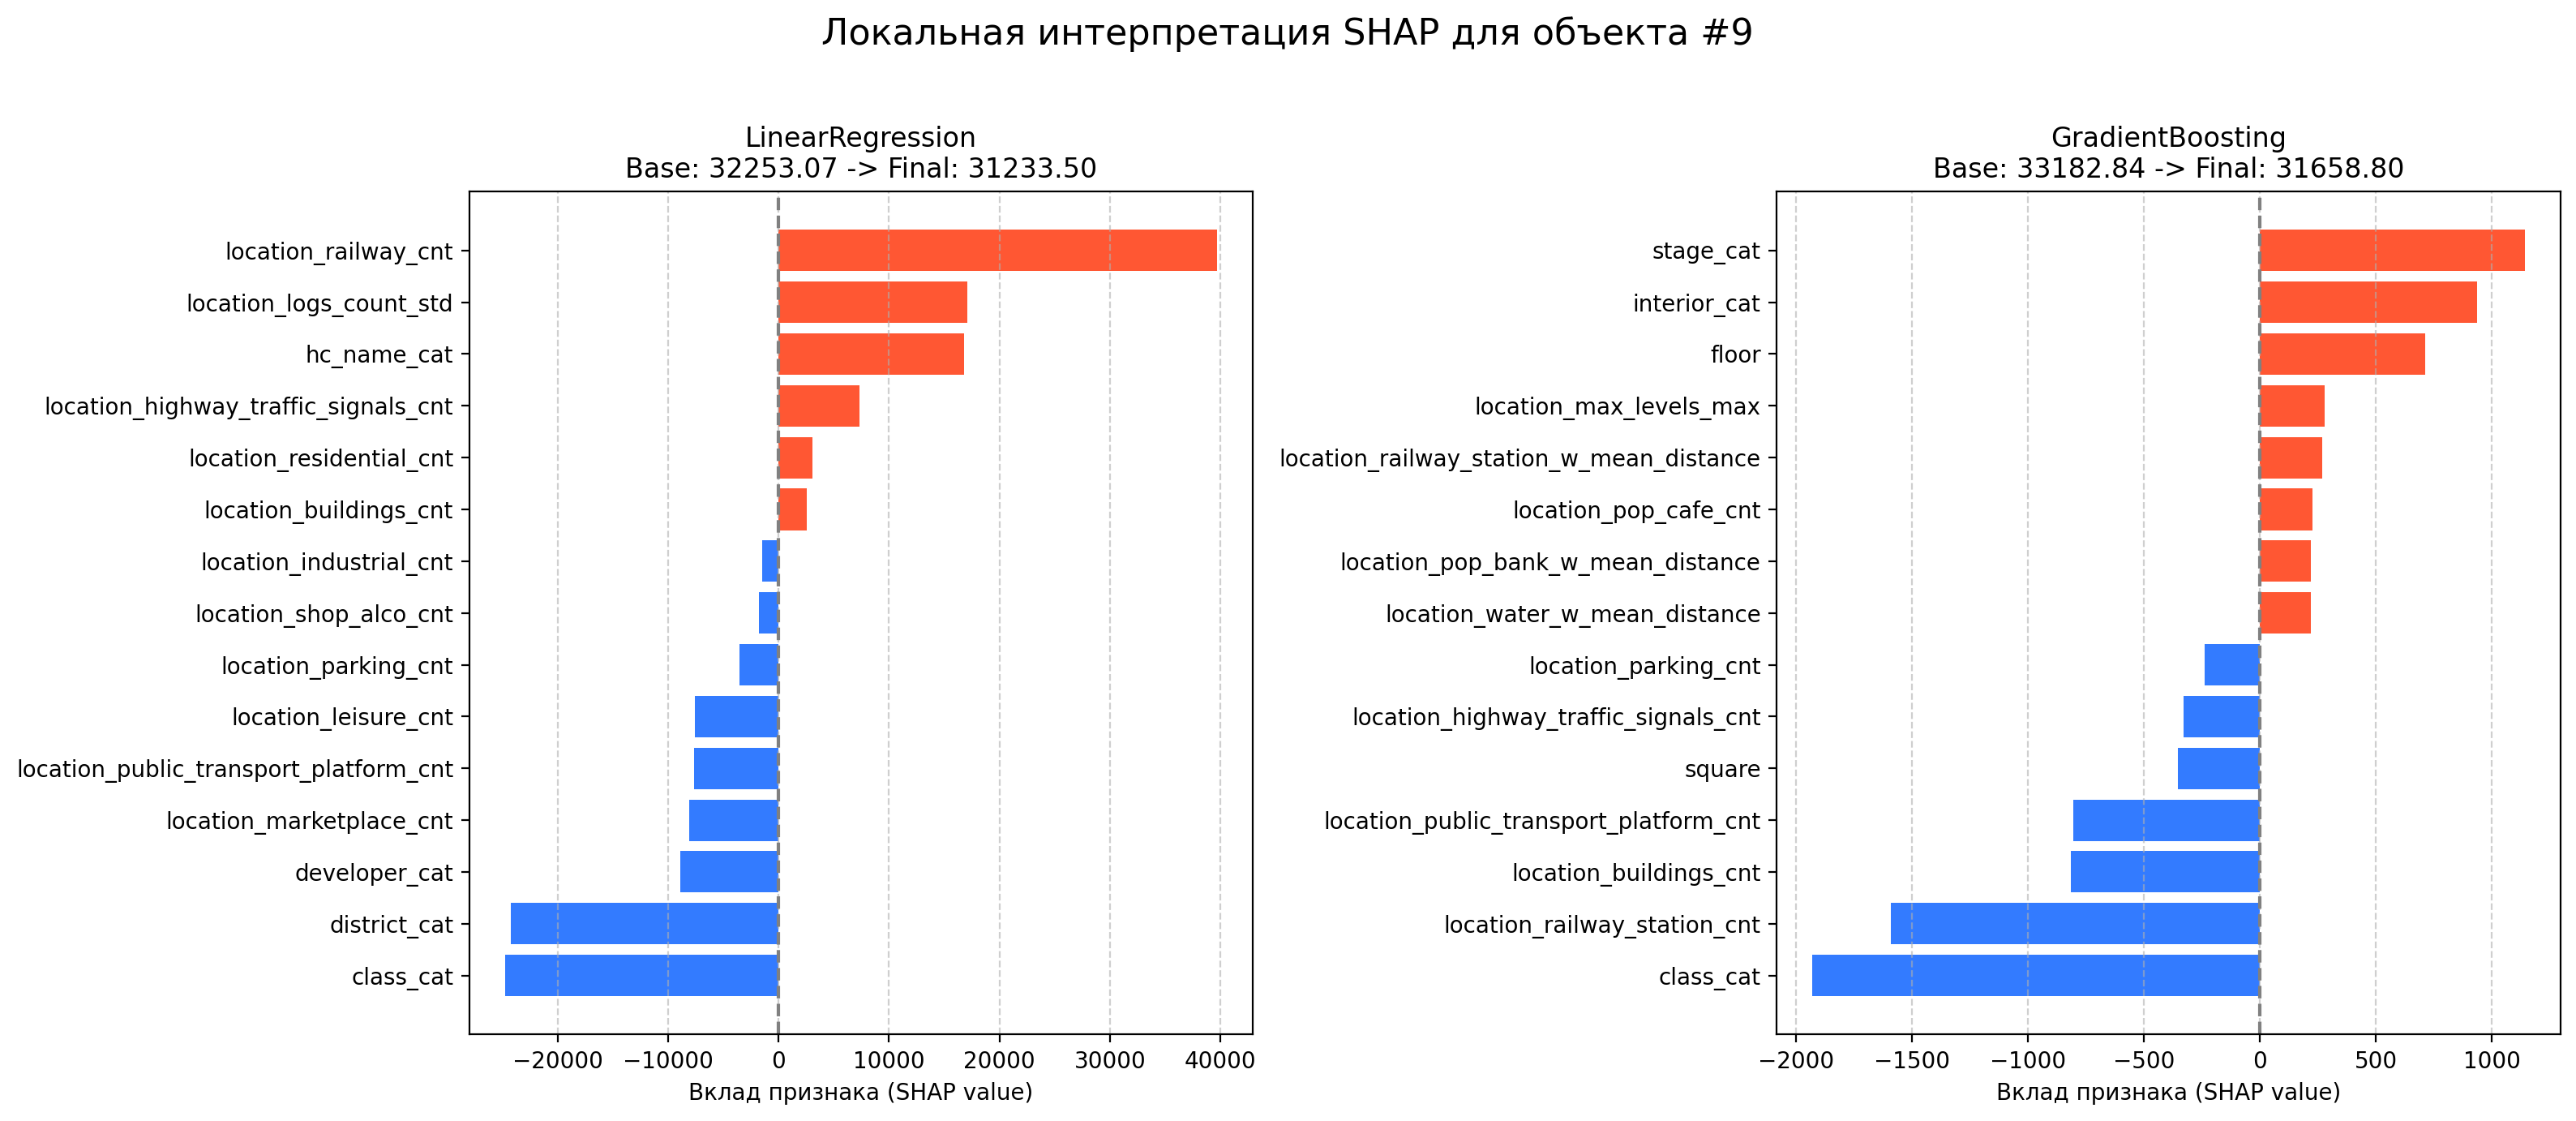

In [52]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


OBJECT_INDEX = 9
x_instance = X_test.iloc[OBJECT_INDEX]

models_to_explain = {
    'LinearRegression': models_traj['LinearRegression'],
    'GradientBoosting': models_traj['GradientBoosting']
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f'Локальная интерпретация SHAP для объекта #{OBJECT_INDEX}', fontsize=16)

for ax, (name, model) in zip(axes, models_to_explain.items()):
    
    if name == 'GradientBoosting':
        explainer = shap.TreeExplainer(model)#treeexplainer для бустинга
    else:
        explainer = shap.LinearExplainer(model, X_train)#и linear для линрег
        
    shap_values = explainer.shap_values(x_instance)
    
    base_value = explainer.expected_value#средняя цена всех квартир в обучающей выборке
    if isinstance(base_value, np.ndarray):
        base_value = base_value[0]
    
    final_prediction = base_value + np.sum(shap_values)
    
    shap_df = pd.DataFrame({
        'feature': x_instance.index,
        'shap_value': shap_values,
        'feature_value': x_instance.values
    })
    
    shap_df['abs_shap'] = shap_df['shap_value'].abs()
    top_shap = shap_df.sort_values(by='abs_shap', ascending=False).head(15).sort_values(by='shap_value')
    
    colors = ['#FF5733' if v > 0 else '#337BFF' for v in top_shap['shap_value']]
    ax.barh(top_shap['feature'], top_shap['shap_value'], color=colors)
    ax.axvline(x=0, color='grey', linestyle='--')
    ax.set_xlabel("Вклад признака (SHAP value)")
    ax.set_title(f'{name}\nBase: {base_value:.2f} -> Final: {final_prediction:.2f}')
    ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

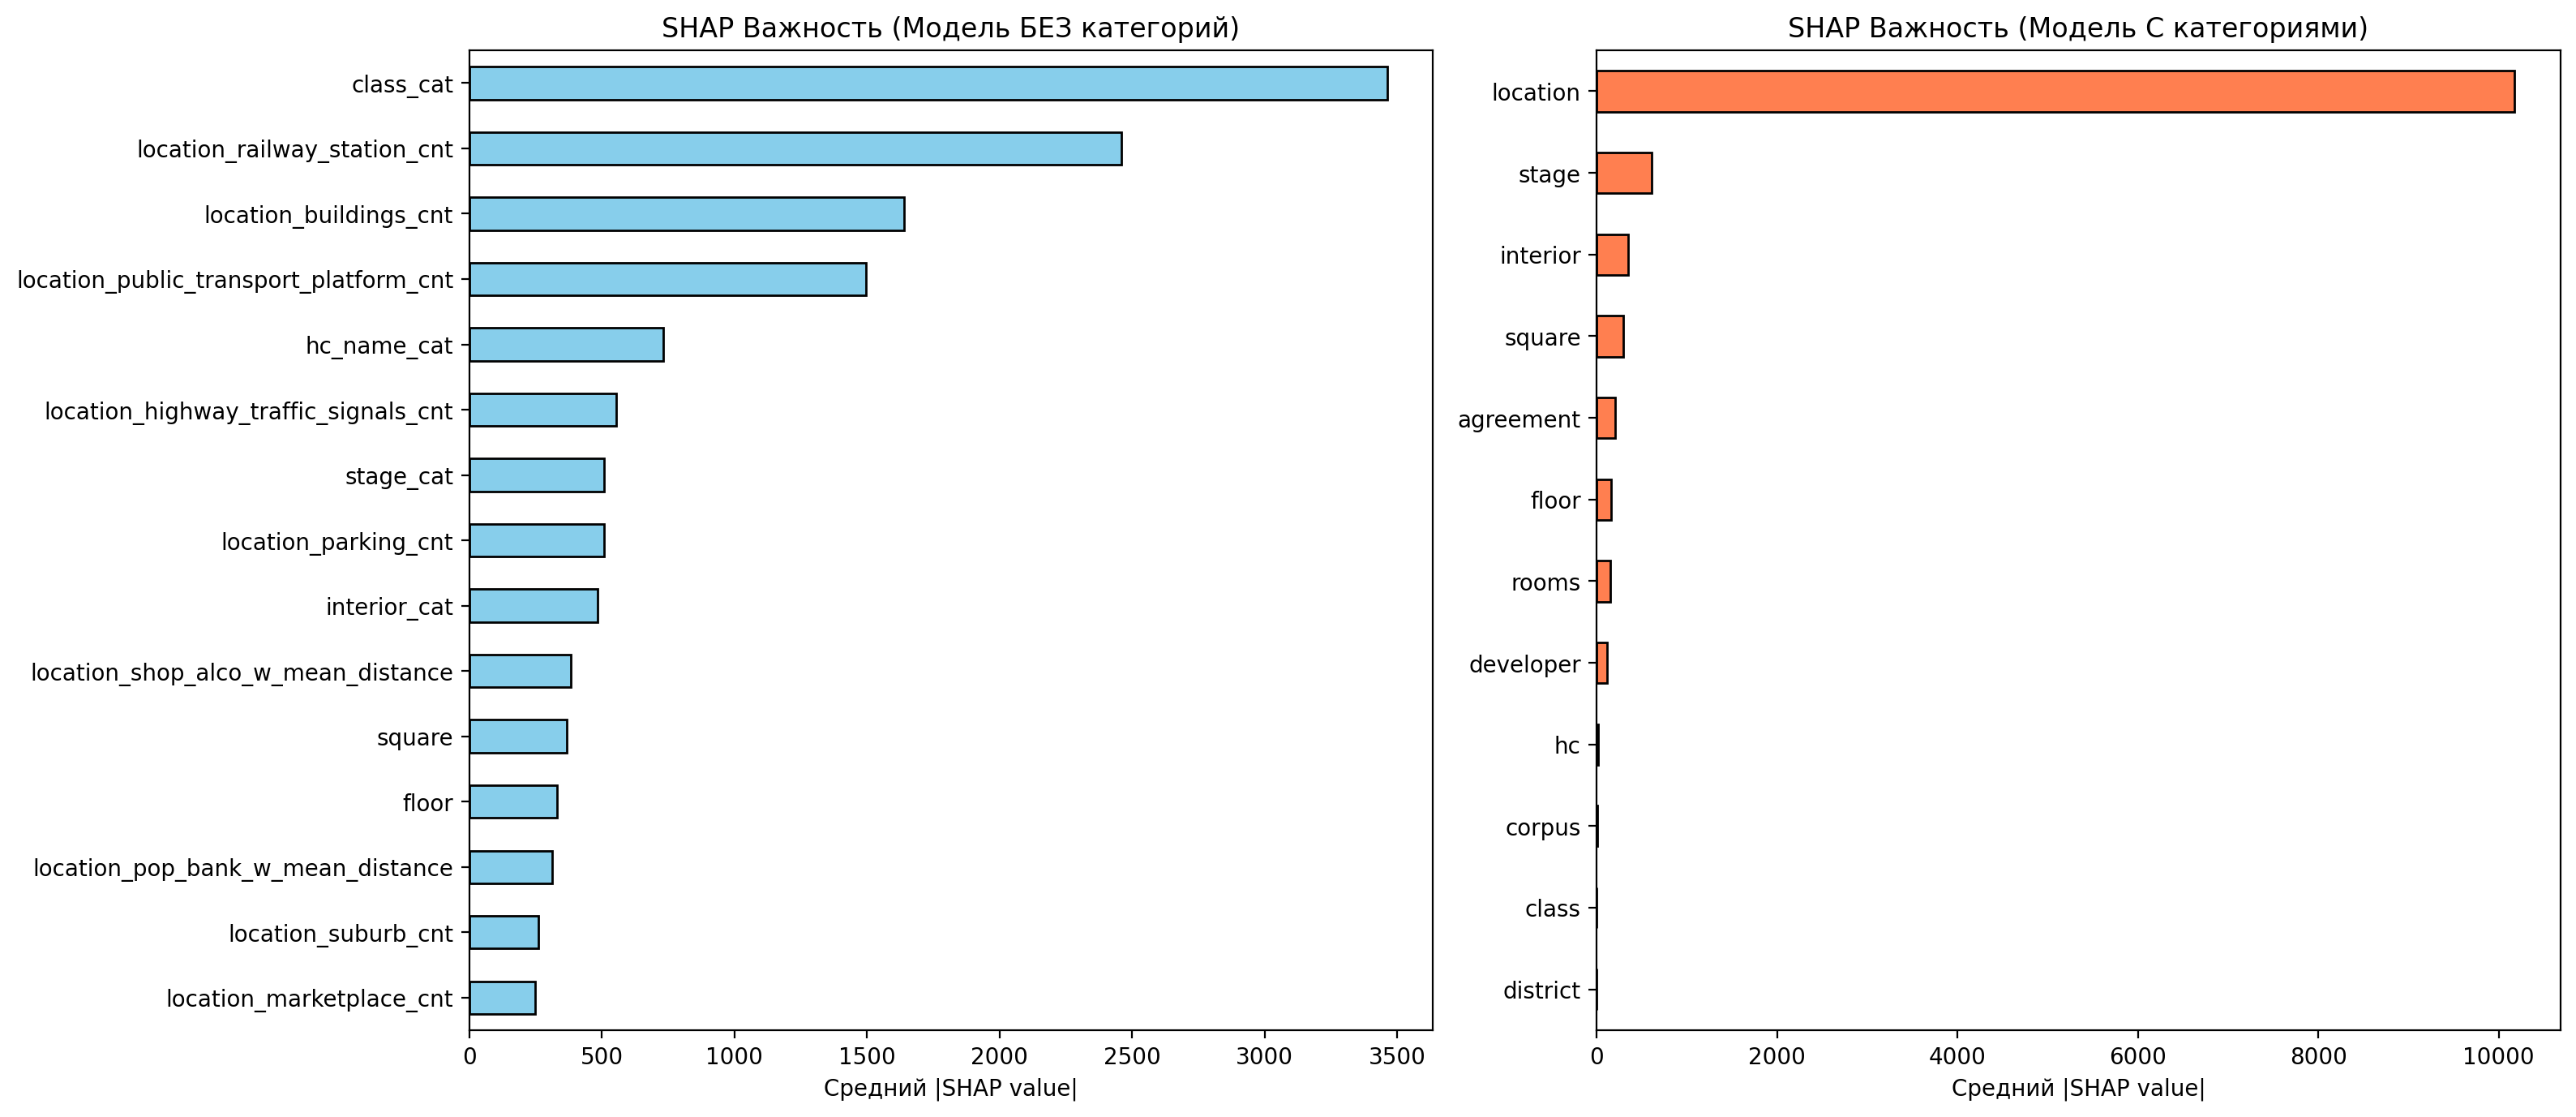

In [54]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

cat_cols = ['region_name_cat', 'district_cat', 'corpus_cat', 'developer_cat', 
            'hc_name_cat', 'interior_cat', 'class_cat', 'stage_cat', 'agreement_date']
target_col = 'price_target'
num_cols = data.select_dtypes(include=['number']).columns.tolist()
if target_col in num_cols: num_cols.remove(target_col)

df_full = data[num_cols + cat_cols + [target_col]].replace(-999.0, np.nan).dropna()
X_full_ohe = pd.get_dummies(df_full.drop(columns=target_col), columns=cat_cols, drop_first=True)
y_full = df_full[target_col]

X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe = train_test_split(X_full_ohe, y_full, test_size=0.2, random_state=42)

gb_ohe = GradientBoostingRegressor(max_depth=5, random_state=42).fit(X_train_ohe, y_train_ohe)
gb_no_cat = GradientBoostingRegressor(max_depth=5, random_state=42).fit(X_train, y_train)

shap_vals_no_cat = shap.TreeExplainer(gb_no_cat).shap_values(X_test)
imp_no_cat = pd.DataFrame(shap_vals_no_cat, columns=X_test.columns).abs().mean().sort_values()

shap_vals_ohe = shap.TreeExplainer(gb_ohe).shap_values(X_test_ohe)
shap_df_ohe = pd.DataFrame(shap_vals_ohe, columns=X_test_ohe.columns)

grouped_shap = shap_df_ohe.groupby(shap_df_ohe.columns.str.split('_').str[0], axis=1).sum()
imp_with_cat = grouped_shap.abs().mean().sort_values()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

imp_no_cat.tail(15).plot(kind='barh', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('SHAP Важность (Модель БЕЗ категорий)')
ax1.set_xlabel('Средний |SHAP value|')

imp_with_cat.tail(15).plot(kind='barh', ax=ax2, color='coral', edgecolor='black')
ax2.set_title('SHAP Важность (Модель С категориями)')
ax2.set_xlabel('Средний |SHAP value|')

plt.tight_layout()
plt.show()